<a href="https://colab.research.google.com/github/JuanZapa7a/Medical-Image-Processing/blob/main/PIM_Challenge/PIM_Challenge_Master_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UPCT Medical Image Segmentation Challenge 2026-27
## Practices 6 to 10
**Course:** Medical Image Processing (521104007)

**Professor:** Juan Zapata

## Session Guide (2 hours per session)
| Practice | Dates (Group A / B) | Session Objective | Visual Checkpoint |
|----------|----------------------|-----------------------|-------------------|
| **P6** | 28 Oct - 2 Nov | EDA, Dataset and RLE format | 6 images with masks + RLE OK |
| **P7** | 9-11 Nov | Baseline U-Net and 1st Submission | Loss curves + Kaggle Submission |
| **P8** | 16-18 Nov | Data Augmentation and improvement | Baseline vs Augmented comparison |
| **P9** | 23-25 Nov | Inference, Threshold and Errors | 5 normal images + 2 error cases |
| **P10** | 30 Nov-2 Dec | TTA, Final Submission and Defense | Best Dice Score + Oral Defense |

> **Golden Rule:** According to Art. 7.5 of the UPCT Assessment Regulations, attendance and validation of the Checkpoint in the classroom is mandatory to pass the practice.

## Download the Competition Dataset

The dataset for this challenge is **private** and is only available inside the competition on Kaggle.

### Instructions:
1. **Accept the invitation** to the challenge that arrived by email (or access it directly):
   [UPCT Medical Image Segmentation Challenge](https://www.kaggle.com/competitions/upct-medical-image-segmentation-challenge-2026-27)

2. Inside the competition, go to the **"Data"** tab (in the top menu).

3. Click on **"Download All"** or download the file **`upct-medical-image-segmentation-challenge-2026-27.zip`** (approx. 150 MB).

4. **Upload the ZIP file** to your Google Drive in a folder named **`PIM_Challenge`**:
   - Go to [Google Drive](https://drive.google.com)
   - Create the `PIM_Challenge` folder (if it doesn't exist)
   - Upload the ZIP there

> **IMPORTANT:**
> - **DO NOT change the ZIP file name** (it must keep its original name)
> - **DO NOT unzip the ZIP** before uploading it (we'll do it from Colab)
> - If you can't access the competition, contact the professor: juan.zapata@upct.es

## Dataset structure

Once unzipped, the dataset will have this structure:

In [ ]:
# ============================================================
# VERIFICATION AND EXPLORATION OF THE DOWNLOADED DATASET
# ============================================================

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2. Install tree to visualize folders
!apt-get install -y tree > /dev/null 2>&1

# 3. Locate the ZIP in PIM_Challenge
import os
import zipfile
import shutil
from pathlib import Path

DRIVE_FOLDER = '/content/drive/MyDrive/PIM_Challenge'
EXTRACT_DIR = Path('/content/PIM_Challenge_dataset')

print(f"\nLooking for dataset in: {DRIVE_FOLDER}\n")

# List folder contents
if os.path.exists(DRIVE_FOLDER):
    print(" Contents of PIM_Challenge:")
    for f in os.listdir(DRIVE_FOLDER):
        size = os.path.getsize(os.path.join(DRIVE_FOLDER, f)) / (1024*1024)
        print(f"   - {f} ({size:.1f} MB)")
else:
    print(f" The folder {DRIVE_FOLDER} does not exist")
    raise FileNotFoundError(DRIVE_FOLDER)

# Look for the ZIP
zip_files = [f for f in os.listdir(DRIVE_FOLDER) if f.endswith('.zip')]

if not zip_files:
    print("\n There is no ZIP file in PIM_Challenge")
    print(" Upload the ZIP you downloaded from Kaggle to that folder")
    raise FileNotFoundError("No ZIP found in PIM_Challenge")

ZIP_PATH = os.path.join(DRIVE_FOLDER, zip_files[0])
print(f"\n ZIP found: {zip_files[0]}")

# 4. Unzip
if not EXTRACT_DIR.exists():
    print(f"\n Unzipping {zip_files[0]}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content')
    print(" Unzipping completed.\n")
else:
    print(f"\n Dataset already unzipped in {EXTRACT_DIR}\n")

# 5. Reorganize if necessary (Kaggle sometimes unzips directly into /content/)
print(" Checking dataset structure...")

if not (EXTRACT_DIR / 'train').exists() and Path('/content/train').exists():
    print(" Dataset unzipped in /content/. Reorganizing...")

    if not EXTRACT_DIR.exists():
        EXTRACT_DIR.mkdir()

    items_to_move = ['train', 'test', 'sample_submission.csv']
    for item in items_to_move:
        src = Path(f'/content/{item}')
        dst = EXTRACT_DIR / item

        if src.exists():
            if dst.exists():
                if dst.is_dir():
                    shutil.rmtree(dst)
                else:
                    dst.unlink()

            shutil.move(str(src), str(dst))
            print(f"   Moved: {item}")
        else:
            print(f"   Not found: {item}")

    print("Reorganization completed.\n")
elif (EXTRACT_DIR / 'train').exists():
    print("Correct structure detected.\n")
else:
    print("Expected structure not found. Looking for train/test folders...\n")

# 6. Show dataset structure
print("="*60)
print(" DATASET STRUCTURE")
print("="*60)
!tree -L 3 /content/PIM_Challenge_dataset --dirsfirst

# 7. Detailed statistics
print("\n" + "="*60)
print(" DETAILED STATISTICS")
print("="*60)

import glob

train_imgs = glob.glob(f'{EXTRACT_DIR}/train/images/*.png')
train_masks = glob.glob(f'{EXTRACT_DIR}/train/masks/*.png')
test_imgs = glob.glob(f'{EXTRACT_DIR}/test/images/*.png')

# Count by class
train_benign = len([f for f in train_imgs if 'benign' in f])
train_malignant = len([f for f in train_imgs if 'malignant' in f])
train_normal = len([f for f in train_imgs if 'normal' in f])

test_benign = len([f for f in test_imgs if 'benign' in f])
test_malignant = len([f for f in test_imgs if 'malignant' in f])
test_normal = len([f for f in test_imgs if 'normal' in f])

print(f"\n TRAIN SET: {len(train_imgs)} images")
print(f"   ├─ Benign:     {train_benign:3d} images")
print(f"   ├─ Malignant:  {train_malignant:3d} images")
print(f"   └─ Normal:     {train_normal:3d} images")
print(f"   Masks:   {len(train_masks)} files")

print(f"\n TEST SET: {len(test_imgs)} images (WITHOUT masks)")
print(f"   ├─ Benign:     {test_benign:3d} images")
print(f"   ├─ Malignant:  {test_malignant:3d} images")
print(f"   └─ Normal:     {test_normal:3d} images")

has_csv = os.path.exists(f'{EXTRACT_DIR}/sample_submission.csv')
print(f"\n sample_submission.csv: {' Exists' if has_csv else ' Does not exist'}")

# 8. Integrity verification
print("\n" + "="*60)
print(" INTEGRITY VERIFICATION")
print("="*60)

checks = [
    (len(train_imgs) == 546, f"Train images: {len(train_imgs)}/546"),
    (len(train_masks) == 546, f"Train masks: {len(train_masks)}/546"),
    (len(test_imgs) == 234, f"Test images: {len(test_imgs)}/234"),
    (has_csv, "sample_submission.csv exists"),
]

all_ok = True
for ok, desc in checks:
    print(f"   {'OK' if ok else 'noOK'} {desc}")
    if not ok:
        all_ok = False

# Final verification
if all_ok:
    print("\n Dataset OK and ready to work with!")
else:
    print("\n There are problems with the dataset. Check the files.")

Mounted at /content/drive

Buscando dataset en: /content/drive/MyDrive/PIM_Challenge

 Contenido de PIM_Challenge:
   - upct-medical-image-segmentation-challenge-2026-27.zip (194.7 MB)
   - checkpoints (0.0 MB)

 ZIP encontrado: upct-medical-image-segmentation-challenge-2026-27.zip

 Descomprimiendo upct-medical-image-segmentation-challenge-2026-27.zip...
 Descompresión completada.

 Verificando estructura del dataset...
 Dataset descomprimido en /content/. Reorganizando...
   Movido: train
   Movido: test
   Movido: sample_submission.csv
Reorganización completada.

 ESTRUCTURA DEL DATASET
/content/PIM_Challenge_dataset
├── test
│   └── images
│       ├── benign (102).png
│       ├── benign (110).png
│       ├── benign (113).png
│       ├── benign (116).png
│       ├── benign (11).png
│       ├── benign (124).png
│       ├── benign (126).png
│       ├── benign (128).png
│       ├── benign (12).png
│       ├── benign (131).png
│       ├── benign (133).png
│       ├── benign (138).png
│ 

# PRACTICE 6: Dataset Exploration and RLE Format
## Single session (28 Oct - Wednesday - and 2 Nov - Monday -)

### Session objectives:
1. Understand the structure of the BUSI dataset (benign, malignant, normal)
2. Visualize images and segmentation masks
3. Understand the RLE format (Run-Length Encoding) for Kaggle
4. Create the DataLoader for training

### Clinical context
The BUSI dataset contains 780 breast ultrasound images:
- **Benign (437)**: Non-cancerous lesions
- **Malignant (210)**: Cancerous lesions
- **Normal (133)**: Healthy tissue (no lesion)

**Clinical challenge**: The model must learn to say "no tumor" on normal images.

> **CHECKPOINT P6:** Show the professor the visualization of images with their masks overlaid and the verification that your `mask_to_rle`/`rle_to_mask` functions correctly reconstruct the original mask.

### Estimated time: 2 hours

## Block 6.1: Semantic Segmentation in Medical Images
### Classification vs Detection vs Segmentation

| Task | Question it answers | Output |
|-------|----------------------|--------|
| **Classification** | Is there a tumor? | Label: "benign" / "malignant" |
| **Detection** | Where is the tumor? | Bounding box |
| **Segmentation** | Which pixels are tumor? | Pixel-by-pixel mask |

### Why segmentation and not classification?
- In medicine, the **size and shape** of the tumor matter (staging)
- It allows computing **volume**, **irregular borders**, **invasion**
- It is the basis of **radiomics** and assisted diagnosis

### The specific challenge: Breast ultrasound (BUS)
- **Noisy** and **low-contrast** images
- **Small** tumors (sometimes < 5% of the image)
- Artifacts: acoustic shadows, reverberations
- **"Normal" class**: the model must learn to NOT detect anything

## Task 6.1: Loading and Structuring the Dataset
Before training any model, we need to organize the information in memory.
We will use the **Pandas** library to create a DataFrame that acts as an index of our dataset, relating each image to its class and its mask.

### Instructions:
1. Define the base path of the dataset: `/content/PIM_Challenge_dataset`.
2. Walk through the `train/images` folder looking for all `.png` images.
3. For each image, extract its **class** (`benign`, `malignant` or `normal`) based on the directory name.
4. Look for the path of its corresponding mask in the `train/masks` folder. *(Hint: the mask name is usually the same as the image but with `_mask` added at the end).*
5. Store all this information in a **Pandas DataFrame** with the columns: `class`, `image_path`, `mask_path` and `filename`.
6. Display the total number of images and the class distribution (how many of each type: benign, malignant and normal).

> **Recommended libraries:** `pandas`, `pathlib`, `os`.

In [ ]:
# ============================================================
# Solution TASK 6.1. LOADING THE DATASET IN PANDAS
# ============================================================
!pip install -q opencv-python

import pandas as pd
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

DATA_DIR = Path('/content/PIM_Challenge_dataset')

# Create a DataFrame with the training image information
data = []
for cls in ['benign', 'malignant', 'normal']:
    img_dir = DATA_DIR / 'train' / 'images'
    mask_dir = DATA_DIR / 'train' / 'masks'

    # Look for images of this class
    for img_path in img_dir.glob(f'*{cls}*.png'):
        # The mask name is usually the same as the image but with _mask.png
        mask_path = mask_dir / f"{img_path.stem}_mask.png"

        data.append({
            'class': cls,
            'image_path': str(img_path),
            'mask_path': str(mask_path) if mask_path.exists() else None,
            'filename': img_path.name
        })

df_train = pd.DataFrame(data)

print(f"Dataset loaded: {len(df_train)} training images.")
print("\nClass distribution in Train:")
print(df_train['class'].value_counts())

Dataset cargado: 546 imágenes de entrenamiento.

Distribución de clases en Train:
class
benign       306
malignant    147
normal        93
Name: count, dtype: int64


## Block 6.2: The BUSI Dataset (Breast Ultrasound Images)
### Origin and composition
- Published by **Al-Dhabyani et al. (2020)**
- 780 breast ultrasound images
- 3 classes:
  - **Benign (437)**: fibroadenomas, cysts...
  - **Malignant (210)**: carcinomas
  - **Normal (133)**: healthy tissue

### Class imbalance

>  **Question to think about:** Why are there more benign than malignant images in clinical reality?

### The "Hidden Challenge": normal images
Most segmentation competitions assume that **every image contains the object to segment**. In this challenge:
- **normal** images have an **empty** mask (all black)
- If your model paints a tumor where there isn't one → **FALSE POSITIVE**
- Clinical consequence: unnecessary biopsy, anxiety, healthcare cost

### Metrics: why don't we use Accuracy?
Imagine a model that says "no tumor" on ALL images:
- Accuracy: ~85% (because 85% of the pixels are background)
- Dice Score: **0** (it didn't detect any tumor)

That's why in medical segmentation we use **Dice Score** or **IoU**.

> **Question to think about:** "If you had to diagnose a patient, what would worry you more: a false positive or a false negative? Why?"

## Task 6.2: Visualization and the "Hidden Clinical Challenge"
We cannot trust the data blindly. Let's visualize the data to make sure the masks are aligned with the images and to understand the clinical difficulty of the challenge.

### Instructions:
1. Select **1 random image of each class** (benign, malignant, normal) from your DataFrame.
2. Create a **3 rows x 3 columns** figure using `matplotlib` (one row per class).
3. For each image, load and display in the 3 columns:
   * **Column 1 (Original):** The image in RGB. *(Remember that `cv2.imread` reads it in BGR, you'll have to convert it).*
   * **Column 2 (Real Mask):** The mask in grayscale.
   * **Column 3 (Overlay):** Copy the original image and **paint in RED `[255, 0, 0]`** the pixels where the mask indicates there is a tumor.
4. Analyze the images of the **"normal"** class. Write a `print()` at the end explaining:
   * What do you see in their masks?
   * What would happen clinically if your AI model predicts a tumor (red pixels) in one of these images?

> **CHECKPOINT P6.1:** When you have the 3x3 figure generated, call the professor so they can validate your visualization and your clinical conclusion.

> **Recommended libraries:** `cv2`, `matplotlib.pyplot`, `numpy`.

/tmp/ipykernel_1044/3663362952.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples = df_train.groupby('class').apply(lambda x: x.sample(1)).reset_index(drop=True)


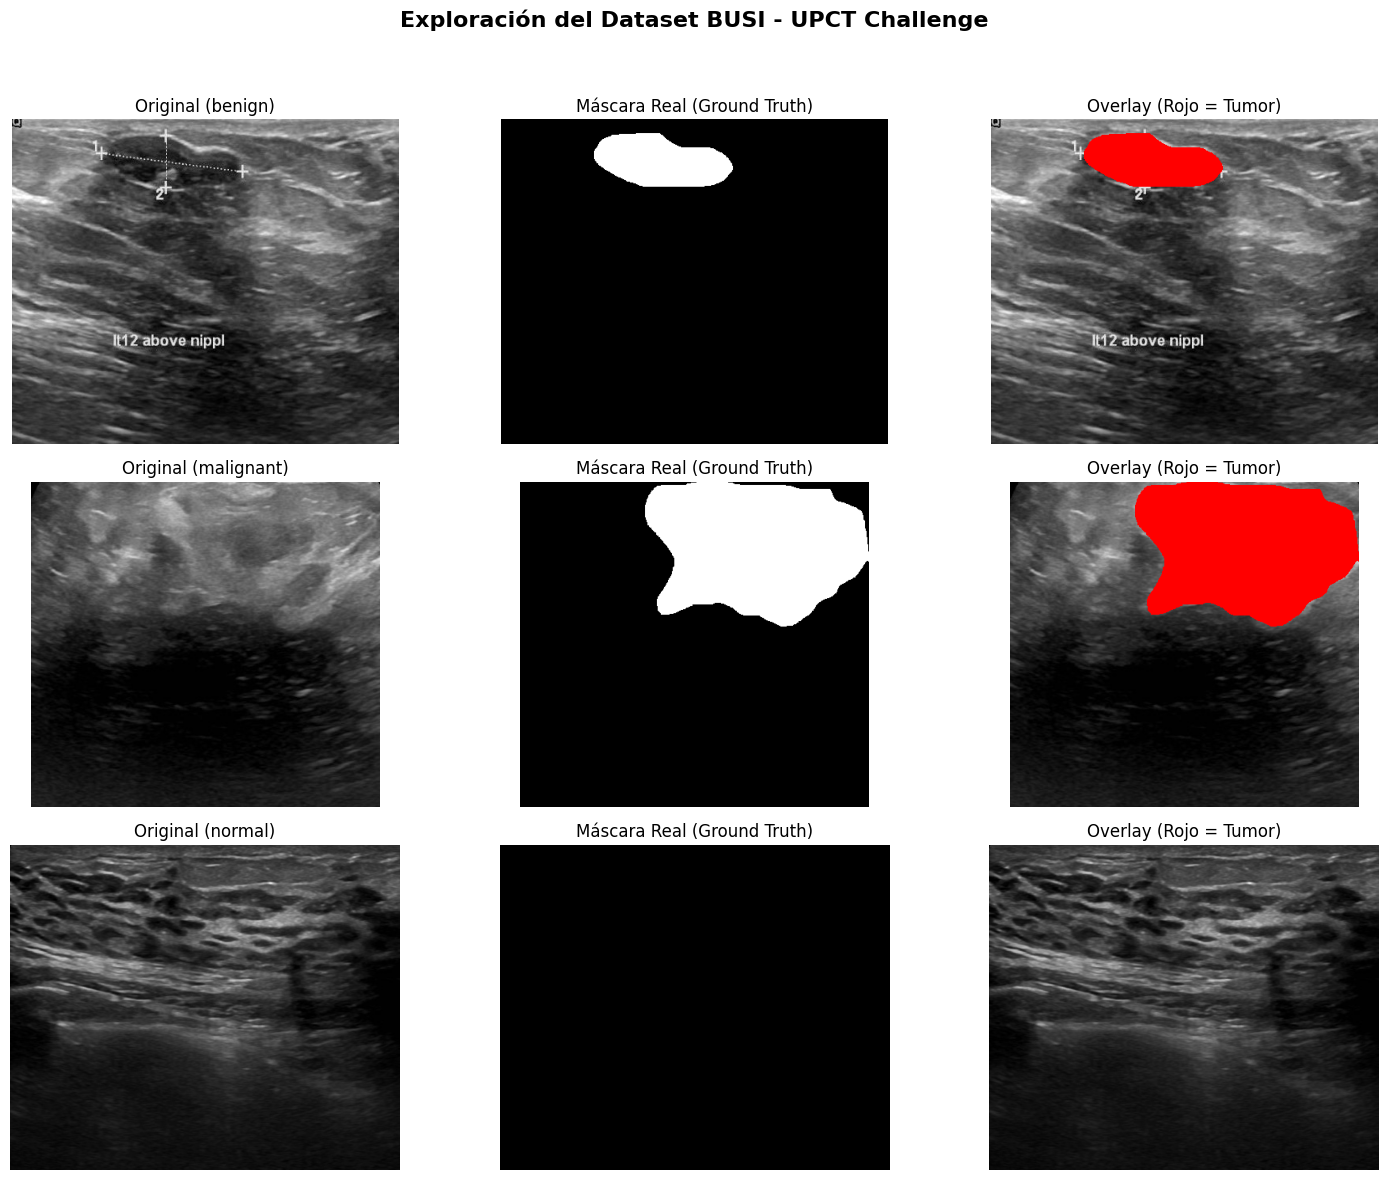


ANÁLISIS DEL RETO OCULTO (Imágenes Normales)
Total imágenes 'normal' en train: 93
Imágenes 'normal' con máscara totalmente negra (vacía): 93/93

 CONCLUSIÓN CLÍNICA:
Si tu modelo predice un tumor en una imagen 'normal', estará cometiendo un FALSO POSITIVO.
En medicina, esto puede llevar a biopsias innecesarias y ansiedad en la paciente.
Tu modelo debe aprender a NO segmentar nada cuando no hay lesión.


In [ ]:
# ============================================================
# Solution TASK 6.2. VISUALIZATION OF EXAMPLES
# ============================================================

def visualize_sample(row, ax_img, ax_mask, ax_overlay):
    """Helper function to load and display image, mask and overlay."""
    # Load image (OpenCV uses BGR, we convert to RGB)
    img = cv2.imread(row['image_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Load mask (in grayscale)
    mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8) # Empty mask by default
    if row['mask_path'] and Path(row['mask_path']).exists():
        mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)

    # Display Original Image
    ax_img.imshow(img)
    ax_img.set_title(f"Original ({row['class']})", fontsize=12)
    ax_img.axis('off')

    # Display Mask (Ground Truth)
    ax_mask.imshow(mask, cmap='gray')
    ax_mask.set_title("Real Mask (Ground Truth)", fontsize=12)
    ax_mask.axis('off')

    # Display Overlay
    overlay = img.copy()
    # Paint in RED the pixels where there is a tumor (mask > 0)
    if mask.max() > 0:
        overlay[mask > 0] = [255, 0, 0]
    ax_overlay.imshow(overlay)
    ax_overlay.set_title("Overlay (Red = Tumor)", fontsize=12)
    ax_overlay.axis('off')

# Select 1 random example of each class
samples = df_train.groupby('class').apply(lambda x: x.sample(1)).reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Exploration of the BUSI Dataset - UPCT Challenge', fontsize=16, fontweight='bold')

for i, (_, row) in enumerate(samples.iterrows()):
    visualize_sample(row, axes[i, 0], axes[i, 1], axes[i, 2])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Analysis of Normal Images
print("\n" + "="*60)
print("ANALYSIS OF THE HIDDEN CHALLENGE (Normal Images)")
print("="*60)

normal_samples = df_train[df_train['class'] == 'normal']
print(f"Total 'normal' images in train: {len(normal_samples)}")

# Check whether the masks of the normal images are really empty
empty_masks = 0
for _, row in normal_samples.iterrows():
    if row['mask_path'] and Path(row['mask_path']).exists():
        mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
        if mask.max() == 0:
            empty_masks += 1

print(f"'normal' images with a completely black (empty) mask: {empty_masks}/{len(normal_samples)}")
print("\n CLINICAL CONCLUSION:")
print("If your model predicts a tumor in a 'normal' image, it is committing a FALSE POSITIVE.")
print("In medicine, this can lead to unnecessary biopsies and anxiety for the patient.")
print("Your model must learn to NOT segment anything when there is no lesion.")

## Block 6.3: Submission Formats and Metrics
### Why RLE and not PNG?
Kaggle needs a **text** format for:
1. **Compression**: a 512x512 mask = 262,144 pixels → in RLE it can be only 20 numbers
2. **Automatic validation**: easy to parse and compare
3. **Multiple objects**: several tumors can be encoded in one image

### Key metrics in Kaggle

**Dice Score (F1 Score):**
$$Dice = \frac{2 \cdot |A \cap B|}{|A| + |B|}$$

**IoU (Intersection over Union):**
$$IoU = \frac{|A \cap B|}{|A \cup B|}$$

**Relationship:** $Dice = \frac{2 \cdot IoU}{1 + IoU}$

| Dice Score | Clinical interpretation |
|------------|----------------------|
| 0.9 - 1.0 | Excellent segmentation |
| 0.7 - 0.9 | Good (typical in competitions) |
| 0.5 - 0.7 | Acceptable, improvable |
| < 0.5 | Model not clinically useful |

### Calculate manually:
"Calculate the Dice of this example by hand:"

    Prediction: 100 tumor pixels
    Ground truth: 100 tumor pixels
    Intersection: 80 pixels
    Answer: Dice = 2·80/(100+100) = 0.80

## Task 6.3: The RLE Format (Run-Length Encoding)
Kaggle does not accept masks as PNG images for submissions. Instead, it requires masks to be sent in text format using **Run-Length Encoding (RLE)**.

### What is RLE?
It is a very simple compression method: instead of storing every pixel, we store **runs of equal pixels**.

**Example:**
Imagine a 5x5 mask (25 pixels) where the center pixels are tumor (1) and the rest is background (0):

0 0 0 0 0

0 1 1 1 0

0 1 1 1 0

0 1 1 1 0

0 0 0 0 0


In RLE format, this is expressed as:
`"7 3 12 3 17 3"`

**What does it mean?**
- `7 3` → Starting at pixel 7, there are 3 tumor pixels
- `12 3` → Starting at pixel 12, there are 3 tumor pixels
- `17 3` → Starting at pixel 17, there are 3 tumor pixels

> **IMPORTANT:** Kaggle reads images **by columns** (top to bottom, then next column), not by rows. And the indices start at **1**, not 0.

### Instructions:
1. Implement the function `mask_to_rle(mask)` that:
   - Receives a binary mask (numpy array of 0s and 1s)
   - Flattens it by columns (use `.T.flatten()`)
   - Detects the transitions from 0 to 1 and from 1 to 0
   - Returns a string in RLE format (pairs of numbers separated by spaces)

2. Implement the function `rle_to_mask(rle_string, height, width)` that:
   - Receives an RLE string and the image dimensions
   - Reconstructs the original binary mask
   - Returns a numpy array of shape `(height, width)`

3. **Test your functions:**
   - Create a test mask (you can use a real mask from the dataset or create an artificial one)
   - Convert it to RLE with `mask_to_rle()`
   - Reconstruct it with `rle_to_mask()`
   - Verify that the original and reconstructed masks are **identical** (use `np.array_equal()`)

4. **Visualize the result:**
   - Show 3 images: original mask, reconstructed mask, and the difference (it should be all black if it works correctly)

> **Hint:** To detect the changes in the pixel sequence, you can use `np.where(pixels[1:] != pixels[:-1])`.

> **CHECKPOINT P6.2:** Show the professor that your RLE functions work correctly (the difference between the original and reconstructed mask must be zero).

Máscara original: forma (465, 557), píxeles de tumor: 4489
RLE encoded (primeros 50 caracteres): 127546 6 128003 17 128468 18 128932 20 129396 21 1...
Máscara reconstruida: forma (465, 557), píxeles de tumor: 4489

¿Son idénticas? True


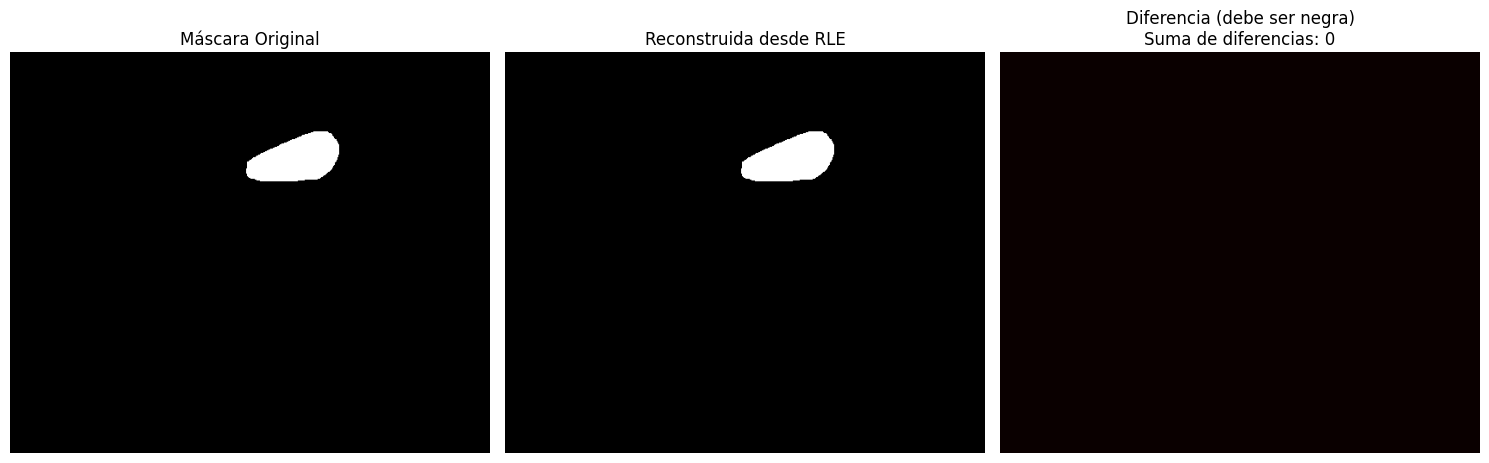


¡Funciona perfectamente! Tus funciones RLE son correctas.


In [ ]:
# ============================================================
# Solution TASK 6.3: RLE IMPLEMENTATION
# ============================================================

import numpy as np

def mask_to_rle(mask):
    """
    Converts a binary mask to RLE format.

    Args:
        mask: binary numpy array (0s and 1s) of shape (height, width)

    Returns:
        str: string in RLE format (pairs of numbers separated by spaces)
    """
    # Flatten by columns (transpose)
    pixels = mask.T.flatten()

    # Detect changes in the sequence
    # We add 0 at the beginning and end to detect borders correctly
    pixels_padded = np.concatenate([[0], pixels, [0]])
    changes = np.where(pixels_padded[1:] != pixels_padded[:-1])[0]

    # The changes alternate between start (0→1) and end (1→0) of regions
    # changes[0] = start of first region, changes[1] = end of first region, etc.
    rle_parts = []
    for i in range(0, len(changes), 2):
        start = changes[i]  # Index where the region starts (0-indexed)
        end = changes[i + 1]  # Index where the region ends (0-indexed)
        length = end - start  # Length of the region

        # Convert to 1-indexed for RLE
        rle_parts.append(f"{start + 1} {length}")

    return " ".join(rle_parts)


def rle_to_mask(rle_string, height, width):
    """
    Converts an RLE string to a binary mask.

    Args:
        rle_string: string in RLE format
        height: height of the image
        width: width of the image

    Returns:
        numpy array: binary mask of shape (height, width)
    """
    # Create pixel array (flattened by columns)
    pixels = np.zeros(height * width, dtype=np.uint8)

    # If the string is empty, return an empty mask
    if not rle_string or rle_string.strip() == "":
        return pixels.reshape((width, height)).T

    # Parse the RLE string
    rle_parts = rle_string.split()

    # Process pairs (start, length)
    for i in range(0, len(rle_parts), 2):
        start = int(rle_parts[i]) - 1  # Convert to 0-indexed
        length = int(rle_parts[i + 1])

        # Mark the pixels as 1
        pixels[start:start + length] = 1

    # Reshape and transpose to get the correct orientation
    # (because we flattened by columns when encoding)
    mask = pixels.reshape((width, height)).T

    return mask

# ============================================================
# TESTING THE FUNCTIONS
# ============================================================

# Load a real mask from the dataset
sample_mask_path = df_train[df_train['class'] == 'benign'].iloc[0]['mask_path']
original_mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)
original_mask_bin = (original_mask > 127).astype(np.uint8)

print(f"Original mask: shape {original_mask_bin.shape}, tumor pixels: {original_mask_bin.sum()}")

# Convert to RLE
rle_encoded = mask_to_rle(original_mask_bin)
print(f"RLE encoded (first 50 characters): {rle_encoded[:50]}...")

# Reconstruct from RLE
reconstructed_mask = rle_to_mask(rle_encoded, original_mask_bin.shape[0], original_mask_bin.shape[1])
print(f"Reconstructed mask: shape {reconstructed_mask.shape}, tumor pixels: {reconstructed_mask.sum()}")

# Verify they are identical
are_equal = np.array_equal(original_mask_bin, reconstructed_mask)
print(f"\nAre they identical? {are_equal}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_mask_bin, cmap='gray')
axes[0].set_title("Original Mask")
axes[0].axis('off')

axes[1].imshow(reconstructed_mask, cmap='gray')
axes[1].set_title("Reconstructed from RLE")
axes[1].axis('off')

difference = np.abs(original_mask_bin.astype(int) - reconstructed_mask.astype(int))
axes[2].imshow(difference, cmap='hot')
axes[2].set_title(f"Difference (must be black)\nSum of differences: {difference.sum()}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

if are_equal:
    print("\nIt works perfectly! Your RLE functions are correct.")
else:
    print("\nThere are differences. Review your implementation.")

# Practice 7: Baseline Model (U-Net) and 1st Submission
## Single session (9 Nov Group A / 11 Nov Group B)

### Session objectives:
1. Create a PyTorch `Dataset` and `DataLoader` to load the images and masks.
2. Define the **U-Net** architecture and the loss function (**Dice Loss + BCE**).
3. Train the model for a few epochs (baseline).
4. Perform inference on the test set and generate the `submission.csv` file.

> **CHECKPOINT P7:** Show the professor the loss curves decreasing and a screenshot of your first submission on the Kaggle Leaderboard.

## Block 7.1: Dataset and DataLoader in PyTorch
### Why is a list of arrays not enough?

So far you have worked with images loaded "by hand" (a standalone `cv2.imread`, a `for` loop). To train a neural network you need something more:

| Without `Dataset`/`DataLoader` | With `Dataset`/`DataLoader` |
|---|---|
| Manual loop loading everything into RAM | Loads **on demand**, one sample at a time |
| Batches built by hand | Groups into **batches** automatically |
| Manual shuffling (or none) | `shuffle=True` reorders each epoch |
| A single process reading from disk | `num_workers` loads in **parallel** |

With 546 images this doesn't seem critical, but it's the same pattern you'll use with datasets of millions of images: **PyTorch doesn't change its API**, only the dataset size changes.

### The abstraction: two pieces with different responsibilities

```
DataFrame (index)            Dataset                    DataLoader
class, image_path,   →    __getitem__(idx)    →      groups N samples
mask_path, filename        returns 1 sample           into a batch
                            (image, mask)             (B, C, H, W)
```

| | `Dataset` | `DataLoader` |
|---|---|---|
| **Answers** | "How do I get sample `i`?" | "How do I group and serve the samples?" |
| **Key methods** | `__len__`, `__getitem__` | — (it's a wrapper) |
| **You decide** | How to load, preprocess and return 1 sample | `batch_size`, `shuffle`, `num_workers` |

> **Key idea:** the `Dataset` knows nothing about batches. It only knows how to return **one** sample given an index. All the logic of grouping, shuffling and parallelizing is the `DataLoader`'s responsibility.

### The segmentation challenge: (image, mask) pairs

In classification, `__getitem__` returns `(image, label)` — the label is a number, it doesn't need to be transformed.

In **segmentation** you return `(image, mask)`, and here there is a trap:

- **Geometric** transformations (resize, flip, rotation) must be applied **identically** to the image and the mask — if you rotate the image 15° but don't rotate the mask, they stop being aligned.
- **Photometric** transformations (normalization, brightness, contrast, noise) only make sense on the **image** — the mask must stay binary (0/1), never "brighten it" or "add noise to it".

> **Question to think about:** if in Practice 8 you rotate the image 15° inside `__getitem__` but forget to rotate the mask, what Dice Score would you expect to get? High, low, or would it depend on the image?

### Normalization: the hidden trap of pretrained encoders

A common normalization is to divide by 255 to bring the pixels to `[0, 1]`. It's correct... **but incomplete** for our case.

Our model (Practice 7) uses a **ResNet34 encoder pretrained on ImageNet** (`encoder_weights="imagenet"`). That encoder was trained with images normalized with the **ImageNet mean and standard deviation**, not with plain `[0, 1]`:

| Channel | Mean | Std |
|-------|-------|--------------------|
| R | 0.485 | 0.229 |
| G | 0.456 | 0.224 |
| B | 0.406 | 0.225 |

```python
image = image.astype(np.float32) / 255.0
image = (image - mean) / std   # mean, std per channel, above
```

If you feed the pretrained encoder with data in `[0, 1]` without centering, the network "sees" an input distribution different from the one it learned — training will still work, but you'll start from a worse position and converge more slowly (and with Data Augmentation, Albumentations does this normalization automatically via `Normalize()`, so from Practice 8 on you won't write it by hand).

### Axis convention: `(H, W, C)` vs `(C, H, W)`

- `cv2` / `numpy` represent an image as `(Height, Width, Channels)`.
- PyTorch expects `(Channels, Height, Width)` for everything that enters a `Conv2d` layer.

```python
image_tensor = torch.tensor(image).permute(2, 0, 1)   # (H,W,C) → (C,H,W)
```

The mask is a special case: it is loaded as `(H, W)` (a single channel, without an explicit channel dimension). Before feeding it to the model it needs a channel dimension: `(1, H, W)` — that's why you'll see `.unsqueeze(0)`.

### Train/Val Split: is random always enough?

`train_test_split(df, test_size=0.2)` distributes rows at random. But remember the "hidden challenge" of Practice 6: the dataset has only 133 `normal` images out of 780. A purely random split does not guarantee that this proportion is maintained in the validation set.

> **Question to think about:** what would happen to your `best_threshold` (Practice 9) if, by bad luck, the split left almost no `normal` images in validation?

*(Hint for those who want to go further: `train_test_split(..., stratify=df['class'])` keeps the class proportions in train and val.)*

### The `DataLoader` parameters

| Parameter | What it does | Practical rule |
|---|---|---|
| `batch_size` | Number of samples per step | Higher = faster, more GPU memory |
| `shuffle` | Reorders the samples each epoch | `True` in train, `False` in val |
| `num_workers` | Loads in parallel from disk | In Colab, 2 workers is usually enough |

> `shuffle=False` in val is not an oversight: this way you always compare the same samples in the same order between epochs.

### Quick summary

| Concept | Main idea |
|----------|----------------|
| `Dataset` | Returns 1 sample given an index (`__getitem__`) |
| `DataLoader` | Groups into batches, shuffles and parallelizes loading |
| Image vs Mask | Same geometric transformation; normalization only on the image |
| Normalization | `/255` is not enough with pretrained encoders (ImageNet mean/std needed) |
| `(H,W,C)` → `(C,H,W)` | numpy/cv2 convention vs PyTorch — use `permute` |
| Train/val split | Simple random split can unbalance minority classes (`normal`) |

### References

1. **PyTorch Docs.** *`torch.utils.data.Dataset` and `DataLoader`.* pytorch.org/docs/stable/data.html
2. **Deng, J., et al. (2009).** *ImageNet: A Large-Scale Hierarchical Image Database.* CVPR. *(origin of the mean/std normalization statistics)*
3. **He, K., et al. (2016).** *Deep Residual Learning for Image Recognition.* CVPR. *(ResNet, the encoder you'll use in the U-Net)*

> Next step: now that you know what each piece should do, implement `BUSIDataset` and its `DataLoader` in Task 7.1.

## Task 7.1: Dataset and DataLoader
To train in PyTorch, we need to package our data.
1. Create a `BUSIDataset` class that inherits from `torch.utils.data.Dataset`.
2. In `__getitem__`, load the image (RGB) and the mask (grayscale).
3. Resize both to `IMG_SIZE` (e.g. 256x256).
4. Normalize the image (divide by 255.0) and binarize the mask (threshold > 127).
5. Return the image as a `(C, H, W)` tensor and the mask as a `(1, H, W)` tensor.
6. Create the `DataLoader`s for train and validation (use 20% for val).

> **Hint:** Use `torch.tensor(img).permute(2, 0, 1)` to change the image format.

In [ ]:
# ============================================================
# Solution TASK 7.1: DATASET AND DATALOADER
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np

# Hyperparameters
IMG_SIZE = 256
BATCH_SIZE = 16

class BUSIDataset(Dataset):
    def __init__(self, dataframe, img_size=256, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.transform = transform  # Added parameter

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # 1. Load image and mask
        image = cv2.imread(row['image_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        if row['mask_path'] and Path(row['mask_path']).exists():
            mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)

        # 2. Resize (only once)
        image = cv2.resize(image, (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size))

        # 3. Binarize mask (values 0 and 1)
        mask = (mask > 127).astype(np.uint8)

        # 4. Normalization and conversion to tensor
        if self.transform is not None:
            # WITH AUGMENTATION: Albumentations already includes Normalize + ToTensorV2
            augmented = self.transform(image=image, mask=mask)
            image_tensor = augmented['image']                    # float32, (3, H, W)
            mask_tensor = augmented['mask'].unsqueeze(0).float() # float32, (1, H, W)
        else:
            # WITHOUT AUGMENTATION: Manual ImageNet normalization
            image = image.astype(np.float32) / 255.0
            mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
            std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
            image = (image - mean) / std

            image_tensor = torch.tensor(image).permute(2, 0, 1)
            mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image_tensor, mask_tensor

# Split the dataset (80% train, 20% val)
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df_train, test_size=0.2, random_state=42)

print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}")

# Create Datasets and DataLoaders
train_dataset = BUSIDataset(train_df)
val_dataset = BUSIDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train samples: 436, Val samples: 110
Train batches: 28, Val batches: 7


## Block 7.2: U-Net Architecture and Loss Function
### Classification vs Detection vs Segmentation

| Task | Question it answers | Output |
|-------|----------------------|--------|
| **Classification** | Is there a tumor? | Label: "benign" / "malignant" |
| **Detection** | Where is the tumor? | Bounding box |
| **Segmentation** | Which pixels are tumor? | Pixel-by-pixel mask |

### Why segmentation and not classification?
- In medicine, the **size and shape** of the tumor matter (staging)
- It allows computing **volume**, **irregular borders**, **invasion**
- It is the basis of **radiomics** and assisted diagnosis

### The specific challenge: Breast ultrasound (BUS)
- **Noisy** and **low-contrast** images
- **Small** tumors (sometimes < 5% of the image)
- Artifacts: acoustic shadows, reverberations
- **"Normal" class**: the model must learn to NOT detect anything

### What is Semantic Segmentation?

Before talking about U-Net, let's remember what we're doing:

| Task | Input | Output |
|-------|---------|--------|
| **Classification** | Image | One label ("benign", "malignant") |
| **Detection** | Image | Bounding boxes + labels |
| **Segmentation** | Image | **Pixel-by-pixel mask** |

In our case, the output is a **binary mask** of the same size as the input image, where each pixel has a value:
- `1` → belongs to the tumor
- `0` → healthy tissue (background)

### U-Net Architecture

#### Origin

Proposed by **Ronneberger et al. (2015)** in the paper *"U-Net: Convolutional Networks for Biomedical Image Segmentation"*. It was designed specifically for **biomedical segmentation** with little training data.

#### Key Idea: "U" Shape

The architecture has a **U** shape because it combines two paths:

```
Input → [ENCODER] → [BOTTLENECK] → [DECODER] → Output
   ↓          ↓              ↓             ↓
  572x572   28x28          4x4           572x572
```

### Encoder (Contractive Path)

The encoder is similar to a classical classification CNN. Its job is to **extract features** and reduce the spatial resolution:

```
Input (256x256x3)
    │
    ▼
[Conv 3x3] → [Conv 3x3] → [MaxPool 2x2]  → 128x128
    │
    ▼
[Conv 3x3] → [Conv 3x3] → [MaxPool 2x2]  → 64x64
    │
    ▼
[Conv 3x3] → [Conv 3x3] → [MaxPool 2x2]  → 32x32
    │
    ▼
[Conv 3x3] → [Conv 3x3] → [MaxPool 2x2]  → 16x16
    │
    ▼
[Conv 3x3] → [Conv 3x3]                  → 8x8  (Bottleneck)
```

**What does the encoder do?**
- Extracts **low-level** features (edges, textures) in the first layers
- Extracts **high-level** features (shapes, complex patterns) in the deep layers
- **Reduces** the spatial resolution but **increases** the channels (more semantic information)

### Bottleneck

It is the deepest point of the network. Here the image has been greatly reduced spatially, but it contains the **most abstract semantic information**.

### Decoder (Expansive Path)

The decoder **reconstructs** the spatial resolution pixel by pixel:

```
Bottleneck (8x8)
    │
    ▼
[UpConv 2x2] → [Conv 3x3] → [Conv 3x3]   → 16x16
    │
    ▼
[UpConv 2x2] → [Conv 3x3] → [Conv 3x3]   → 32x32
    │
    ▼
[UpConv 2x2] → [Conv 3x3] → [Conv 3x3]   → 64x64
    │
    ▼
[UpConv 2x2] → [Conv 3x3] → [Conv 3x3]   → 128x128
    │
    ▼
[Conv 1x1] + Sigmoid                         → 256x256x1 (Mask)
```

### Skip Connections: The "Secret" of U-Net

Here is the **key innovation**: the **skip connections** that link the encoder with the decoder:

```
Encoder                    Decoder
   │                          │
   ├──[feat1]──────────────►[+ merge]──►
   │                          │
   ├──[feat2]──────────────►[+ merge]──►
   │                          │
   ├──[feat3]──────────────►[+ merge]──►
   │                          │
   └──[feat4]──────────────►[+ merge]──►
                              │
                           [Output]
```

**Why are they so important?**

| Without Skip Connections | With Skip Connections |
|---------------------|---------------------|
| Only semantic information | Semantic information **+** precise localization |
| Blurry borders | Sharp borders |
| Loses fine details | Recovers fine details |

> **Analogy:** Imagine the decoder is a painter who has to reconstruct a painting. The encoder gives him the "general idea" (what is painted), but the skip connections pass him the "original sketches" so he can paint with precision.

### Loss Function: Dice Loss + BCE

In our notebook we use a **combined loss function**:

```python
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / \
                    (probs.sum() + targets.sum() + self.smooth)

        return bce_loss + dice_loss
```

### 1. Binary Cross Entropy (BCE)

It is the classical loss for binary classification, applied **pixel by pixel**:

$$\text{BCE} = -\frac{1}{N}\sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \right]$$

Where:
- $y_i$ = real value of pixel $i$ (0 or 1)
- $\hat{y}_i$ = model prediction for pixel $i$
- $N$ = total number of pixels

**Intuition:**
- If the real pixel is `1` and you predict `0.9` → **low** penalty
- If the real pixel is `1` and you predict `0.1` → **high** penalty

**Problem of BCE in segmentation:**
- Medical images have **extreme class imbalance**
- Example: in a 256×256 = 65,536 pixel image, maybe only 500 are tumor (~0.7%)
- BCE treats all pixels equally → the model can learn to predict everything as "background" and still have good accuracy

### 2. Dice Loss

Based on the **Dice Coefficient** (or *F1 Score*):

$$\text{Dice} = \frac{2 \cdot |A \cap B|}{|A| + |B|}$$

Where:
- $A$ = pixels predicted as tumor
- $B$ = real tumor pixels
- $|A \cap B|$ = intersection (correctly classified pixels)

The **Dice Loss** is simply:

$$\text{Dice Loss} = 1 - \text{Dice} = 1 - \frac{2 \cdot |A \cap B| + \epsilon}{|A| + |B| + \epsilon}$$

The $\epsilon$ (smooth) term avoids **division by zero** when both masks are empty.

**Visual intuition:**

```
    A (Prediction)          B (Ground Truth)        A ∩ B (Intersection)
    ┌─────────┐             ┌─────────┐             ┌─────────┐
    │  ████   │             │   ████  │             │   ███   │
    │  ████   │             │   ████  │             │   ███   │
    │  ████   │             │   ████  │             │   ███   │
    └─────────┘             └─────────┘             └─────────┘

    Dice = 2·(intersection) / (|A| + |B|)
```

**Advantages of Dice Loss:**
- **Robust to class imbalance**
- Directly optimizes the **metric we care about** (Dice Score)
- Works well with **small objects** (small tumors)

**Disadvantages of Dice Loss:**
- Unstable at the beginning of training (noisy gradients)
- Does not consider the **spatial localization** of each individual pixel

### Why combine them?

| Loss | Strength | Weakness |
|---------|-----------|-----------|
| **BCE** | Stable gradients, considers each pixel | Sensitive to imbalance |
| **Dice** | Robust to imbalance | Unstable gradients at the start |

**Combining them gives us the best of both worlds:**

$$\mathcal{L}_{total} = \mathcal{L}_{BCE} + \mathcal{L}_{Dice}$$

- **BCE** provides stable gradients from the first batch
- **Dice** pushes the model to maximize the segmentation metric
- Together they converge faster and to better results

## Application to Our Challenge

In the *UPCT Medical Image Segmentation Challenge*:

```python
# U-Net model with pre-trained ResNet34 encoder
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

# Combined loss
criterion = DiceBCELoss(smooth=1.0)

# Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)
```

### Complete flow:

```
Image (256×256×3)
    │
    ▼
[Encoder ResNet34] → Extracts hierarchical features
    │
    ▼
[Decoder] → Reconstructs mask with skip connections
    │
    ▼
Logits (256×256×1)
    │
    ▼
[Sigmoid] → Probabilities [0, 1]
    │
    ▼
[Threshold 0.5] → Binary mask
    │
    ▼
[DiceBCELoss] → Compare with ground truth
    │
    ▼
[Backpropagation] → Update weights
```


### References

1. **Ronneberger, O., Fischer, P., & Brox, T. (2015).** *U-Net: Convolutional Networks for Biomedical Image Segmentation.* MICCAI.
2. **Sudre, C. H., et al. (2017).** *Generalised Dice overlap as a deep learning loss function for highly unbalanced segmentations.* Deep Learning in Medical Image Analysis.
3. **Milletari, F., Navab, N., & Ahmadian, S. A. (2016).** *V-Net: Fully convolutional neural networks for volumetric medical image segmentation.* 3DV.


### Quick Summary

| Concept | Main Idea |
|----------|----------------|
| **U-Net** | Encoder + Decoder + Skip Connections |
| **Encoder** | Extracts features, reduces resolution |
| **Decoder** | Reconstructs the mask pixel by pixel |
| **Skip Connections** | Preserve high-level spatial information |
| **BCE** | Pixel-by-pixel loss, stable but sensitive to imbalance |
| **Dice Loss** | Robust to imbalance, optimizes the final metric |
| **Dice + BCE** | The best of both worlds |

> **Next step:** In practice, we will implement U-Net with `segmentation_models_pytorch` and train with the combined loss. Let's code!

## Task 7.2: U-Net Model and Loss Function
We will use the `segmentation_models_pytorch` (smp) library to create a U-Net with a pre-trained backbone (ResNet34).
1. Define the `smp.Unet` model with `encoder_weights='imagenet'` and `activation=None` (important for the loss since we use BCEWithLogitsLoss).
2. Define a custom loss class `DiceBCELoss` that combines `BinaryCrossEntropyWithLogitsLoss` and `DiceLoss`.
3. Configure the `Adam` optimizer.

In [ ]:
# ============================================================
# Solution TASK 7.2: MODEL AND LOSS
# ============================================================
# Install the libraries needed for segmentation
!pip install -q segmentation_models_pytorch timm

import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# 1. Define the U-Net model
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None, # Important: we use BCEWithLogitsLoss
)
model = model.to(DEVICE)

# 2. Define the loss function (BCE) (Binary Cross Entropy with Logits)
# criterion = nn.BCEWithLogitsLoss()

# # Define the combined loss function (Dice)
# class DiceLoss(nn.Module):
#     def __init__(self, smooth=1.0):
#         super().__init__()
#         self.smooth = smooth

#     def forward(self, logits, targets):
#         probs = torch.sigmoid(logits)

#         intersection = (probs * targets).sum()
#         dice = (2. * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)

#         return 1 - dice  # We return 1 - dice because we want to minimize the loss

# criterion = DiceLoss().to(DEVICE)

# Define the combined loss function (Dice + BCE)
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)

        return bce_loss + dice_loss

criterion = DiceBCELoss().to(DEVICE)

# 3. Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.8 MB/s eta 0:00:00
Usando dispositivo: cuda


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

## Block 7.3: The Training Loop in PyTorch
### Anatomy of a training step

  Each batch goes through the same five lines, always in the same order. It's worth memorizing the order because the three most common PyTorch bugs come from breaking it:

  ```python
  optimizer.zero_grad()   # 1. Zero the gradients from the previous step
  logits = model(images)  # 2. Forward pass
  loss = criterion(logits, masks)  # 3. Compute the loss
  loss.backward()         # 4. Backward pass (computes gradients)
  optimizer.step()        # 5. Update the weights with those gradients
  ```

  | Step | What it does | What happens if you forget or omit it |
  |------|----------|----------------------------------|
  | `optimizer.zero_grad()` | Clears the gradients accumulated from the previous batch | Gradients **add up** between batches; the model learns poorly and erratically |
  | `model(images)` | Computes the prediction (logits, without sigmoid yet) | — |
  | `criterion(logits, masks)` | Compares prediction vs. real mask | — |
  | `loss.backward()` | Computes how much each weight contributes to the error (gradients) | Without this, `optimizer.step()` has nothing to update |
  | `optimizer.step()` | Moves the weights in the direction that reduces the error | Without this, the model never changes even if you compute gradients |


### Epochs, batches and steps

Three words that are easily confused:

| Term | Definition | In our case |
|---------|------------|------------------|
| **Step** | One weight update = one processed batch | `optimizer.step()` once |
| **Batch** | A group of `batch_size` samples | 16 images (`BATCH_SIZE = 16`) |
| **Epoch** | One complete pass over the whole `train_loader` | `len(train_loader)` steps |

`len(train_loader)` is not the number of images, it's the number of **batches**: approximately `num_samples / batch_size`. If you have 437 train samples and `batch_size=16`, each epoch is 28 steps, not 437.

### The difference between `model.train()` and `model.eval()`

Your encoder (ResNet34) uses **BatchNorm** layers. These layers behave differently depending on the mode:

| Mode | BatchNorm uses... | When to activate it |
|------|-------------------|--------------------|
| `model.train()` | Statistics of the current batch (mean/variance) | During training |
| `model.eval()` | Statistics accumulated over the whole training | During validation and inference |

If you evaluate with the model in `train()` mode, the result depends on which other images are in that validation batch — two runs with the same model can give different Dice Scores. That's why, before each validation phase, calling `model.eval()` is mandatory, and before training again, `model.train()` once more.

### How `torch.no_grad()` behaves during validation

When training, PyTorch builds a computation graph to be able to compute gradients with `backward()`. That graph consumes memory and time.

During validation you **won't call `backward()`**, so that graph is wasted work. `torch.no_grad()` tells PyTorch not to build it:

```python
model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        ...
```

Without `torch.no_grad()`, the validation loop is still *correct* (the numerical result doesn't change), but it's slower and can exhaust GPU memory on large datasets.


### Averaging the metric per epoch

Inside the loop you accumulate the loss and the Dice **per batch**:

```python
epoch_train_loss += loss.item()
```

When all the batches of the epoch finish, you have to divide by the number of batches to get the true average:

```python
epoch_train_loss /= len(train_loader)
```

If you forget this division, the number you print is not a per-batch loss but a **running sum**, which grows with each batch inside the same epoch and is not comparable between epochs with a different number of batches.

### Why save Loss and Dice, not just one

The loss function (`DiceBCELoss`) is what **optimizes** the model, but it isn't necessarily the metric you care about as a clinical or competition result. Saving both lets you detect situations where they diverge:

| Situation | Loss | Dice | Interpretation |
|-----------|------|------|-----------------|
| Normal case | Low | Rising | The model improves in both senses |
| Deceptive plateau | Slowly decreasing | Stagnant | The loss keeps being optimized but it doesn't translate into better real segmentation |
| Train/val divergence | Train drops, Val rises | Train rises, Val drops | Sign of overfitting (you'll see it in detail in Practice 8) |

> **Note:** Kaggle doesn't evaluate your Loss, it evaluates the Dice Score on the test set. The Loss is only the signal you use internally to train.

### Keep the best model, not the last one (checkpointing)

The loop above trains the full `NUM_EPOCHS` epochs and, when it finishes, `model` contains the weights of the **last** epoch — not necessarily the best one. If the Val Dice goes up and down from one epoch to another (something normal, not a bug), the last epoch can be worse than an earlier one already seen.

The solution is to save a copy of the weights every time the Val Dice improves, and at the end of the loop recover that copy:

```python
if epoch_val_dice > best_val_dice:
    best_val_dice = epoch_val_dice
    torch.save(model.state_dict(), 'best_model.pth')
```

`model.state_dict()` is a dictionary with all the model weights at that moment; `torch.save` stores it on disk. At the end of the loop, `model.load_state_dict(torch.load('best_model.pth'))` overwrites the current `model` weights with the ones you saved — so any later code (Task 7.4, Practice 9, Practice 10) that uses `model` is automatically using the best checkpoint, without needing to change anything else.

> **Key idea:** saving only the number (`max(val_dices)`) is useless if you don't also save the weights that produced it — the number without the weights is just a statistical curiosity.

### Why Google Drive and not the Colab disk

These practices are done on different days. Every day you open Colab it's a **new runtime**: the local disk (`/content/...`) is wiped completely, so a checkpoint saved there only survives within the session where you created it. If you saved the checkpoint only locally, you'd have to retrain the model from scratch every day just to have `model` ready again, before even being able to start the new task of the day.

Google Drive does persist between sessions. You already mounted the `DRIVE_FOLDER` folder in Practice 6 to download the dataset — we reuse that same folder to also save the checkpoints, in a `checkpoints/` subfolder.

With this, each training cell follows this logic:

| Situation | What the cell does |
|-----------|---------------------|
| No checkpoint exists in Drive (first time) | Trains the `NUM_EPOCHS` epochs normally and, when finished, saves weights + history (Loss/Dice) in Drive |
| A checkpoint already exists in Drive (session from a previous day) | Loads the weights and the saved history directly — **does not retrain** |

> **Key idea:** the Drive checkpoint is not only the model weights — it also includes the `train_losses`, `val_losses`, `train_dices` and `val_dices` history, because the plots and comparisons of later tasks (for example, Task 8.4) need those lists even if the model was trained days ago.

### Quick summary

| Concept | Main idea |
|----------|-----------------|
| `zero_grad → forward → loss → backward → step` | Fixed order; skipping `zero_grad` accumulates gradients between batches |
| Epoch vs batch vs step | One epoch = `len(train_loader)` steps, not the number of images |
| `model.train()` / `model.eval()` | Changes BatchNorm behavior; mandatory to alternate between phases |
| `torch.no_grad()` | Avoids building the gradient graph in validation (memory and speed) |
| Accumulate and divide | Sum per batch, divide by `len(loader)` at the end of the epoch |
| Loss vs Dice | Loss optimizes, Dice is what is really evaluated |
| Checkpointing | Save the best Val Dice weights and reload them at the end; otherwise you're left with the last epoch's |
| Checkpoint in Drive | Persists between sessions on different days; the cell checks if it already exists and avoids retraining if so |

## Task 7.3: Training Loop
It's time to train.
1. Create a loop for `NUM_EPOCHS` (start with 5 or 10 for the class, it's to check that everything works correctly).
2. In each epoch, iterate over the `train_loader`: forward pass, compute loss, backward pass and `optimizer.step()`.
3. At the end of each epoch, evaluate the model on the `val_loader` (in `model.eval()` mode and with `torch.no_grad()`).
4. Save the train and val losses in lists to plot at the end. It's interesting to watch the dice in both training and validation since that's what kaggle will score.
5. Save the model weights (`torch.save(model.state_dict(), ...)`) every time the validation Val Dice improves compared to previous epochs, and when the loop finishes load those weights into `model` with `load_state_dict`. This way you keep the best model, not the one from the last epoch.
6. Save the final checkpoint (weights + history) in the Google Drive folder where the dataset is (`DRIVE_FOLDER`, mounted in P6), not only on the local Colab disk — so it persists between sessions on different days. At the beginning of the cell, check whether a checkpoint from a previous session already exists in Drive: if it does, load it directly (along with the Loss/Dice history) and don't train again.

> **CHECKPOINT P7.1:** Show the professor the loss curves decreasing (training and validation) and the Dice Score increasing (training and validation)

Checkpoint encontrado en Google Drive: /content/drive/MyDrive/PIM_Challenge/checkpoints/baseline_checkpoint.pth
Cargando el mejor modelo de una sesión anterior (no hace falta reentrenar)...
Modelo cargado. Mejor Val Dice: 0.7490

Generando gráficos...


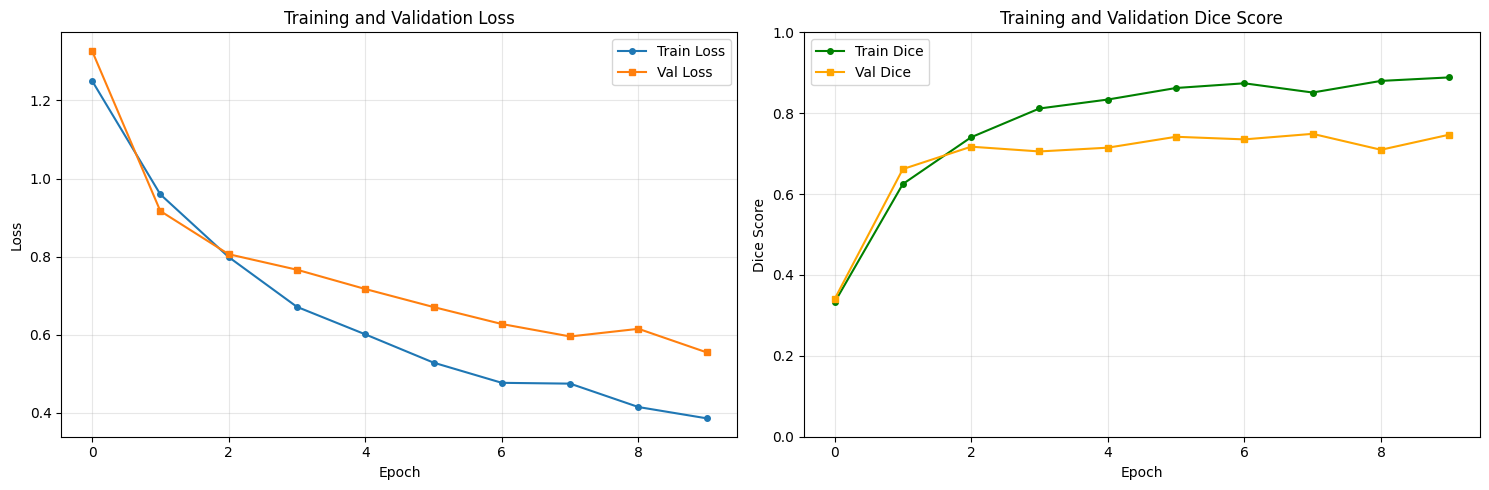


¡Entrenamiento completado!
 Mejor Dice Score en validación: 0.7490 (Epoch 8)


In [ ]:
# ============================================================
# Solution TASK 7.3: TRAINING (WITH DICE SCORE)
# ============================================================
from tqdm.notebook import tqdm  # tqdm.notebook for Colab (visual bars)
from pathlib import Path

NUM_EPOCHS = 10

# Checkpoint folder in Google Drive (persists between different sessions/days)
CHECKPOINT_DIR = Path(DRIVE_FOLDER) / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_CHECKPOINT_PATH = CHECKPOINT_DIR / 'baseline_checkpoint.pth'

train_losses = []
val_losses = []
train_dices = []
val_dices = []

if DRIVE_CHECKPOINT_PATH.exists():
    # This model was already trained in a previous session: load it instead of retraining
    print(f"Checkpoint found in Google Drive: {DRIVE_CHECKPOINT_PATH}")
    print("Loading the best model from a previous session (no need to retrain)...")
    checkpoint = torch.load(DRIVE_CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    train_dices = checkpoint['train_dices']
    val_dices = checkpoint['val_dices']
    best_val_dice = checkpoint['best_val_dice']
    print(f"Model loaded. Best Val Dice: {best_val_dice:.4f}")

else:
    best_val_dice = -1
    BEST_MODEL_PATH = 'best_model_baseline.pth'  # local checkpoint, only for this session

    print("Starting training...")
    print(f"Epochs: {NUM_EPOCHS}")
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches: {len(val_loader)}")
    print("="*60)

    for epoch in range(NUM_EPOCHS):
        # Training Phase
        model.train()
        epoch_train_loss = 0
        epoch_train_dice = 0

        # Progress bar for the train loop
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False)

        for images, masks in train_bar:
            images, masks = images.to(DEVICE), masks.to(DEVICE)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

            # Compute Dice Score
            with torch.no_grad():
                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).float()
                intersection = (preds * masks).sum()
                union = preds.sum() + masks.sum()
                dice = (2. * intersection + 1e-6) / (union + 1e-6)
                epoch_train_dice += dice.item()

            # Update the bar description with loss and dice
            train_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'dice': f'{dice.item():.4f}'
            })

        epoch_train_loss /= len(train_loader)
        epoch_train_dice /= len(train_loader)

        # Validation Phase
        model.eval()
        epoch_val_loss = 0
        epoch_val_dice = 0

        # Progress bar for the val loop
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]", leave=False)

        with torch.no_grad():
            for images, masks in val_bar:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                logits = model(images)
                loss = criterion(logits, masks)
                epoch_val_loss += loss.item()

                # Compute Dice Score
                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).float()
                intersection = (preds * masks).sum()
                union = preds.sum() + masks.sum()
                dice = (2. * intersection + 1e-6) / (union + 1e-6)
                epoch_val_dice += dice.item()

                # Update the bar description
                val_bar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'dice': f'{dice.item():.4f}'
                })

        epoch_val_loss /= len(val_loader)
        epoch_val_dice /= len(val_loader)

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_dices.append(epoch_train_dice)
        val_dices.append(epoch_val_dice)

        # Save local checkpoint if it's the best model so far (according to Val Dice)
        is_best = epoch_val_dice > best_val_dice
        if is_best:
            best_val_dice = epoch_val_dice
            torch.save(model.state_dict(), BEST_MODEL_PATH)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
        print(f"   Train - Loss: {epoch_train_loss:.4f} | Dice: {epoch_train_dice:.4f}")
        print(f"   Val   - Loss: {epoch_val_loss:.4f} | Dice: {epoch_val_dice:.4f}")
        if is_best:
            print(f"   -> New best model saved ({BEST_MODEL_PATH})")
        print("-"*60)

    # Restore the best model weights (not the last epoch's)
    model.load_state_dict(torch.load(BEST_MODEL_PATH))

    # Save to Google Drive so we don't have to retrain in future sessions
    torch.save({
        'model_state_dict': model.state_dict(),
        'best_val_dice': best_val_dice,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_dices': train_dices,
        'val_dices': val_dices,
    }, DRIVE_CHECKPOINT_PATH)
    print(f"\nBest model weights restored in 'model' (Val Dice: {best_val_dice:.4f})")
    print(f"Checkpoint saved in Google Drive: {DRIVE_CHECKPOINT_PATH}")

# Loss plots
print("\nGenerating plots...")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', marker='o', markersize=4)
axes[0].plot(val_losses, label='Val Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dice Score plot
axes[1].plot(train_dices, label='Train Dice', marker='o', markersize=4, color='green')
axes[1].plot(val_dices, label='Val Dice', marker='s', markersize=4, color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].set_title('Training and Validation Dice Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"\nTraining completed!")
print(f" Best Dice Score in validation: {max(val_dices):.4f} (Epoch {val_dices.index(max(val_dices)) + 1})")

## Block 7.4: From Training to Submission
### What changes (and what doesn't) when moving to inference

Training and predicting on test share almost all the code, with three key differences:

| | Training / Validation | Inference on test |
|---|---|---|
| Model mode | `model.train()` in train, `model.eval()` in val | `model.eval()` always |
| Gradients | Computed in train (`loss.backward()`) | Never (`torch.no_grad()`) |
| Are there real `masks`? | Yes, to compute loss and Dice | No — test has no mask |
| Output of interest | A number (loss, Dice) to compare models | A binary mask to send to Kaggle |

> **Note:** since test has no real mask, you cannot compute your Dice Score locally on these images. The only way to know how well your model does there is to upload the submission and look at the Leaderboard.

### The preprocessing must be identical to training

This is the point where it's easiest to introduce a silent bug. The model learned from images preprocessed in a specific way (Block 7.1: resize to `IMG_SIZE`, normalization with ImageNet mean/std). If you preprocess differently at inference — even if it's "only" skipping the ImageNet normalization and staying at `/255.0` — the model receives data with a distribution different from what it saw in training, and its performance drops without any error being raised.

```python
# Must be the SAME preprocessing as in BUSIDataset (Block 7.1), step by step:
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img_norm = img_resized.astype(np.float32) / 255.0
img_norm = (img_norm - mean) / std          # the same ImageNet mean/std
img_tensor = torch.tensor(img_norm).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
```

> **Question to think about:** if you train with ImageNet normalization but at inference you only divide by 255, will the model raise an error, or simply give worse predictions without warning? Why is the second case more dangerous?

### The predicted mask doesn't have the original size

The model always works at `IMG_SIZE x IMG_SIZE` (for example 256x256), but each test image has its own original size. Kaggle expects the mask at the image's original resolution, so you have to undo the resize before encoding in RLE:

```
Original image (H0, W0)
        │  resize to IMG_SIZE
        ▼
Model → mask (IMG_SIZE, IMG_SIZE)
        │  resize back to (H0, W0)
        ▼
Mask at original size → mask_to_rle()
```

Save `original_h, original_w` **before** resizing the input image — it's easy to forget and be left with only the already-rescaled size.

### From probability to binary mask

The model doesn't directly return a mask — it returns **logits**, which have to be converted in two steps:

| Step | Operation | Result |
|------|-----------|-----------|
| 1. Logits → probability | `torch.sigmoid(logits)` | Continuous values between 0 and 1 |
| 2. Probability → binary mask | `(probs > threshold)` | Values 0 or 1 |

Here we use `threshold = 0.5` because it's the reasonable default value, but there's no guarantee it's the best cut for this problem — in Practice 9 you'll search for the `best_threshold` specific to your model.

### Reusing `mask_to_rle`: why not rewrite it

You already implemented the `mask_to_rle` function in Practice 6. The idea of a well-organized `Dataset`/pipeline is precisely this: each piece (data loading, model, RLE encoding) is written once and reused in all the following practices. If you have to copy and paste the same RLE logic in every practice, that's a sign that it should be kept in a utilities cell at the beginning of the notebook instead of repeating it.

### The format of `submission.csv`

Kaggle validates the submission by comparing exact columns against `sample_submission.csv`:

| Column | Content |
|---------|-----------|
| `Id` | Image file name (must match the test one exactly) |
| `Expected` | The RLE string of the predicted mask for that image |

A row with a misspelled `Id`, or an RLE with indices that don't fit the declared dimensions, makes Kaggle reject or score that row badly — it's worth comparing your `submission.csv` against `sample_submission.csv` (same number of rows, same `Id`s) before uploading it.

### Quick summary

| Concept | Main idea |
|----------|-----------------|
| Test set | Has no masks; you'll only know your real Dice after uploading to Kaggle |
| Preprocessing | Must be identical to training (resize + normalization), or the model performs worse without raising an error |
| Resize the mask | The model predicts at `IMG_SIZE`; you must return the mask to the original size before RLE |
| Logits → mask | `sigmoid()` gives probabilities, a `threshold` turns them into a binary mask |
| `mask_to_rle` | Reuse the one from Practice 6, don't rewrite it |
| `submission.csv` | Columns `Id` and `Expected`; compare against `sample_submission.csv` before uploading |

## Task 7.4: Inference and Submission to Kaggle
The model is trained! Now we need to predict on the test images.
1. Iterate over the images in the `test/images` folder.
2. Pass the image through the model (remember to preprocess it the same as in train).
3. Apply `torch.sigmoid()` to the output and threshold it (e.g. > 0.5) to get the binary mask.
4. Resize the mask to the original image size.
5. Convert the mask to RLE format using the `mask_to_rle` function from Practice 6.
6. Save the results in a DataFrame and export it as `submission.csv`.

> **CHECKPOINT P7.2:** Download the `submission.csv` and upload it to Kaggle. Show your position on the Leaderboard!

In [ ]:
# ============================================================
# Solution TASK 7.4: INFERENCE AND SUBMISSION
# ============================================================
# (We assume mask_to_rle is already defined in the notebook)

test_img_dir = DATA_DIR / 'test' / 'images'
test_images = list(test_img_dir.glob('*.png'))

results = []

print("Generating predictions for the test set...")
model.eval()
with torch.no_grad():
    for img_path in test_images:
        # 1. Load and preprocess image (identical to BUSIDataset preprocessing, Task 7.1)
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        original_h, original_w = img_rgb.shape[:2]

        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
        img_norm = img_resized.astype(np.float32) / 255.0

        # ImageNet normalization: must be IDENTICAL to BUSIDataset (Task 7.1),
        # or the model receives data with a distribution different from training
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img_norm = (img_norm - mean) / std

        img_tensor = torch.tensor(img_norm, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

        # 2. Predict
        logits = model(img_tensor)
        probs = torch.sigmoid(logits)
        mask_pred = (probs > 0.5).float()

        # 3. Resize mask to the original size
        mask_np = mask_pred.squeeze().cpu().numpy()
        mask_resized = cv2.resize(mask_np, (original_w, original_h))
        mask_binary = (mask_resized > 0.5).astype(np.uint8)

        # 4. Convert to RLE and save
        rle = mask_to_rle(mask_binary)
        results.append({'Id': img_path.name, 'Expected': rle})

# Create DataFrame and save
submission_df = pd.DataFrame(results)
submission_df.to_csv('submission.csv', index=False)
print(" submission.csv generated correctly. Upload it to Kaggle!")

Generando predicciones para el test set...
 submission.csv generado correctamente. ¡Súbelo a Kaggle!


In [ ]:
# ============================================================
# Solution TASK 7.4: INFERENCE AND SUBMISSION (with optimized Dice)
# ============================================================

# Show the best Dice obtained during training
print("=" * 60)
print(" MODEL PERFORMANCE")
print("=" * 60)
print(f" Best Dice Score in validation: {max(val_dices):.4f}")
print(f" Epoch with best performance: {val_dices.index(max(val_dices)) + 1}/{NUM_EPOCHS}")
print(f" Final validation loss: {val_losses[-1]:.4f}")
print()

# ============================================================
# THRESHOLD OPTIMIZATION BASED ON DICE
# ============================================================
# The 0.5 threshold is not always optimal for medical segmentation
# We can tune it to maximize the Dice Score

# Default threshold (you can adjust it based on your results)
# If your Dice is low (< 0.7), try higher thresholds (0.6-0.7)
# If you have many false negatives, try lower thresholds (0.3-0.4)
THRESHOLD = 0.5  # ← Adjust this value according to your analysis

print(f" Selected threshold: {THRESHOLD}")
print(" Tip: If the model predicts too much, increase the threshold")
print(" Tip: If the model doesn't detect enough tumors, decrease the threshold")
print()

# ============================================================
# GENERATION OF PREDICTIONS
# ============================================================

test_img_dir = DATA_DIR / 'test' / 'images'
test_images = list(test_img_dir.glob('*.png'))

results = []

print(" Generating predictions for the test set...")
print(f" Total images: {len(test_images)}")
print()

model.eval()
with torch.no_grad():
    for idx, img_path in enumerate(test_images):
        # Load image (identical to BUSIDataset preprocessing, Task 7.1)
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        original_h, original_w = img_rgb.shape[:2]

        # Preprocessing
        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
        img_norm = img_resized.astype(np.float32) / 255.0

        # ImageNet normalization: must be IDENTICAL to BUSIDataset (Task 7.1),
        # or the model receives data with a distribution different from training
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img_norm = (img_norm - mean) / std

        img_tensor = torch.tensor(img_norm, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

        # Prediction
        logits = model(img_tensor)
        probs = torch.sigmoid(logits)

        # Apply optimized threshold
        mask_pred = (probs > THRESHOLD).float()

        # Post-processing
        mask_np = mask_pred.squeeze().cpu().numpy()
        mask_resized = cv2.resize(mask_np, (original_w, original_h))
        mask_binary = (mask_resized > 0.5).astype(np.uint8)

        # Convert to RLE
        rle = mask_to_rle(mask_binary)
        results.append({'Id': img_path.name, 'Expected': rle})

        # Show progress every 50 images
        if (idx + 1) % 50 == 0:
            print(f"   Progress: {idx + 1}/{len(test_images)} images processed")

# ============================================================
# CREATE AND SAVE SUBMISSION
# ============================================================

submission_df = pd.DataFrame(results)
submission_df.to_csv('submission.csv', index=False)

# Submission statistics
total_images = len(submission_df)
images_with_tumor = (submission_df['Expected'] != '').sum()
images_without_tumor = (submission_df['Expected'] == '').sum()

print()
print("=" * 60)
print(" SUBMISSION GENERATED CORRECTLY")
print("=" * 60)
print(f" Total images: {total_images}")
print(f" Images with tumor detected: {images_with_tumor}")
print(f" Images without tumor (normal): {images_without_tumor}")
print(f" Detection percentage: {(images_with_tumor/total_images)*100:.1f}%")
print()
print(" Ready to upload to Kaggle!")
print(" File: submission.csv")
print()
print(" RECOMMENDATIONS:")
print("   1. If your validation Dice was < 0.7, consider:")
print("      - Increasing the number of epochs")
print("      - Adjusting the learning rate")
print("      - Using data augmentation")
print("   2. If you detect many false positives:")
print("      - Increase the threshold (e.g. 0.6 or 0.7)")
print("   3. If you detect many false negatives:")
print("      - Decrease the threshold (e.g. 0.3 or 0.4)")

 RENDIMIENTO DEL MODELO
 Mejor Dice Score en validación: 0.7490
 Época con mejor rendimiento: 8/10
 Loss final en validación: 0.5547

 Threshold seleccionado: 0.5
 Tip: Si el modelo predice demasiado, aumenta el threshold
 Tip: Si el modelo no detecta suficientes tumores, disminuye el threshold

 Generando predicciones para el test set...
 Total de imágenes: 234

   Progreso: 50/234 imágenes procesadas
   Progreso: 100/234 imágenes procesadas
   Progreso: 150/234 imágenes procesadas
   Progreso: 200/234 imágenes procesadas

 SUBMISSION GENERADA CORRECTAMENTE
 Total de imágenes: 234
 Imágenes con tumor detectado: 215
 Imágenes sin tumor (normales): 19
 Porcentaje de detección: 91.9%

 ¡Listo para subir a Kaggle!
 Archivo: submission.csv

 RECOMENDACIONES:
   1. Si tu Dice en validación fue < 0.7, considera:
      - Aumentar el número de épocas
      - Ajustar el learning rate
      - Usar data augmentation
   2. Si detectas muchos falsos positivos:
      - Aumenta el threshold (ej: 0.6 

# Practice 8: Data Augmentation and Model Improvement
## Single session (16 Nov Group A / 18 Nov Group B)

### Session objectives:
1. Understand Data Augmentation techniques specific to medical images
2. Implement an augmentation pipeline with Albumentations
3. Re-train the model with augmented data
4. Compare results: Baseline vs Augmented

### Golden rules in medical images:
- **DO**: Small rotations (±15° or less), flips, smooth elastic deformations, brightness/contrast adjustment
- **DON'T**: 90° rotations (loses anatomical orientation), aggressive crops (loss of context), extreme deformations

> **CHECKPOINT P8:** Show the professor:
> 1. Visualization of 4-6 transformations applied to the same image
> 2. Comparison table: Baseline vs Augmented (Dice Score)

## Block 8.1: Data Augmentation in Medical Images
### From memorization to generalization

In Block 7.3 we saw this warning sign:

| Situation | Loss | Dice | Interpretation |
|-----------|------|------|-----------------|
| Train/val divergence | Train drops, Val rises | Train rises, Val drops | Sign of overfitting |

With only 546 training images, a model with millions of parameters (ResNet34 + decoder) has more than enough capacity to **memorize** the specific images it sees, instead of learning patterns that **generalize** to new images. The symptom is exactly that divergence: the model improves on train but stops improving (or gets worse) on val.

### Data Augmentation as regularization

The idea is not to get more patients or more real ultrasounds: it's to fabricate **artificial variations** of the images you already have, so the model never sees exactly the same image twice.

| Without augmentation | With augmentation |
|---|---|
| The model can memorize the 437 exact image-mask pairs | Each epoch sees slightly different versions (rotated, brighter, with noise...) |
| It also learns the specific noise of those images | Only what is truly **invariant** survives (the tumor shape, not the exact brightness of that ultrasound) |

> **Key idea:** Data Augmentation doesn't add new information about the world — it forces the model not to depend on irrelevant details of each specific image.

### Two families of transformations

In Block 7.1 we already distinguished two types of transformation in a segmentation `Dataset`, and this is where it really matters:

| Type | Examples | Is it applied to the mask? |
|------|----------|----------------------------|
| Geometric | Flip, rotation, shift/scale, elastic transform | Yes, exactly the same as to the image |
| Photometric | Brightness, contrast, gaussian noise | No — the mask stays binary (0/1) |

If you rotate the image but not the mask (or the other way around), the model trains with misaligned pairs: it will learn to segment badly, with a Dice that collapses without any code error to reveal it.

### Why not all transformations are valid in medical imaging

A 90° rotation or a vertical flip are perfectly valid transformations for cat photos, but not here:

| Transformation | Clinical problem |
|-----------------|-------------------|
| 90°/180° rotation | In breast ultrasound the probe orientation is clinically relevant; rotating like this creates images that don't correspond to any real acquisition |
| Aggressive crops | Can remove the tumor completely from the image without removing it from the mask |
| Extreme elastic deformations | A tumor deformed beyond what is physiologically possible teaches the model shapes that don't exist in reality |

The general rule: **a transformation is only valid if the result could have been a real acquisition** in the clinic. That's why rotations are limited to ±10-15° (plausible variation in the probe angle) and not full turns.

### How a pipeline is composed in Albumentations

```python
train_augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
```

Two details that usually go unnoticed:

- Each `p=` is an **independent** probability per transformation: `p=0.5` doesn't mean "half of the images are transformed", it means *that* specific transformation is applied with 50% probability, combining with the others.
- `A.Normalize` + `ToTensorV2` automatically do what you wrote by hand in Block 8.1 (ImageNet normalization + conversion to a `(C,H,W)` tensor). That's why from here on you won't repeat that code manually.

### Augment only train, never val or test

`train_augment` is applied exclusively to the training `DataLoader`. The validation one keeps using the simple preprocessing of Block 8.1.

> **Question to think about:** if you also applied augmentation to the validation set, would it still be a reliable measure of how the model generalizes to new data, or would you be fooling yourselves?

The reason is simple: val and test must reflect the real distribution the model will see in production (an ultrasound as the machine captures it, not a rotated version with added noise). If you measure on artificially augmented data, the metric stops being comparable with the Kaggle Leaderboard.

> **Question to think about:** training with augmentation adds extra variability each epoch — would you expect the model to converge as fast as the Practice 7 baseline, with the same number of epochs, or would it need more time for the improvement to show?

### Quick summary

| Concept | Main idea |
|----------|-----------------|
| Overfitting | Train improves, val stagnates or worsens — sign of memorization |
| Data Augmentation | Regularization: artificial variations that prevent memorizing irrelevant details |
| Geometric transformation | Applied equally to image and mask |
| Photometric transformation | Applied only to the image |
| Medical rules | Only transformations that could correspond to a real acquisition |
| `p=` in Albumentations | Independent probability per transformation, not a fraction of the dataset |
| Scope | Augmentation only in train; val/test keep the simple preprocessing |

### References

1. **Shorten, C., & Khoshgoftaar, T. M. (2019).** *A survey on Image Data Augmentation for Deep Learning.* Journal of Big Data.
2. **Buslaev, A., et al. (2020).** *Albumentations: Fast and Flexible Image Augmentations.* Information.

## Task 8.1: Why Data Augmentation?
### The overfitting problem
When we train with few data (546 images), the model tends to **memorize** instead of **generalize**. This shows up as:
- Train Loss drops a lot
- Val Loss stagnates or rises
- Train Dice high, Val Dice low

### The solution: Data Augmentation
It consists of creating **artificial variations** of the training images to:
1. Increase the effective size of the dataset
2. Force the model to learn invariant features
3. Reduce overfitting

### Transformations specific to breast ultrasound:

| Transformation | Recommended parameter | Clinical justification |
|----------------|----------------------|----------------------|
| **Horizontal Flip** | p=0.5 | The left/right breast is symmetric |
| **Vertical Flip** | p=0.3 | Less common but valid |
| **Rotation** | ±15° | The probe can have varied angles |
| **Elastic Transform** | alpha=1, sigma=50 | Simulates tissue deformations |
| **Gaussian Noise** | var_limit=(10,50) | Simulates equipment noise |
| **Brightness/Contrast** | ±0.2 | Variations in equipment gain |

>  **IMPORTANT**: The masks must be transformed **the same way** as the images to keep the alignment.

In [ ]:
# ============================================================
# Solution TASK 8.1: DATA AUGMENTATION PIPELINE
# ============================================================
import albumentations as A
from albumentations.pytorch import ToTensorV2

# train_augment = A.Compose([
#     A.Resize(IMG_SIZE, IMG_SIZE),
#     A.HorizontalFlip(p=0.5),
#     A.VerticalFlip(p=0.3),
#     A.RandomRotate90(p=0.3),
#     A.ShiftScaleRotate(
#         shift_limit=0.05,
#         scale_limit=0.1,
#         rotate_limit=15,
#         p=0.5
#     ),
#     A.ElasticTransform(
#         alpha=1,
#         sigma=50,
#         alpha_affine=0,
#         p=0.3
#     ),
#     A.GaussNoise(
#         var_limit=(10, 50),
#         p=0.3
#     ),
#     A.RandomBrightnessContrast(
#         brightness_limit=0.2,
#         contrast_limit=0.2,
#         p=0.5
#     ),
#     A.Normalize(
#         mean=(0.485, 0.456, 0.406),
#         std=(0.229, 0.224, 0.225)
#     ),
#     ToTensorV2()
# ])

train_augment = A.Compose([
    # REMOVED: A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    # REMOVED: VerticalFlip (unrealistic in breast ultrasound)
    # REMOVED: RandomRotate90 (changes anatomical orientation)

    # Smooth rotation (the probe can vary ±10°)
    A.Rotate(limit=10, p=0.5, border_mode=cv2.BORDER_CONSTANT),

    # Very smooth Shift/Scale
    A.ShiftScaleRotate(
        shift_limit=0.02,      # previously 0.05
        scale_limit=0.05,      # previously 0.1
        rotate_limit=0,        # we already have a separate Rotate
        p=0.5,
        border_mode=cv2.BORDER_CONSTANT
    ),

    # REMOVED: ElasticTransform (destroys small tumors)

    # Smooth gaussian noise (simulates equipment noise)
    # A.GaussNoise(var_limit=(5, 20), p=0.3),  # previously (10, 50)

    # Smooth brightness/contrast
    A.RandomBrightnessContrast(
        brightness_limit=0.1,   # previously 0.2
        contrast_limit=0.1,     # previously 0.2
        p=0.5
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])


print("Augmentation pipeline defined")

Pipeline de augmentation definido


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Block 8.2: Visually Verifying an Augmentation Pipeline
### Why visualize before training

A misconfigured Albumentations pipeline doesn't raise any error — it simply trains with silently deformed data. Discovering this after 30 training epochs (several minutes or hours of GPU) is much more expensive than discovering it by looking at a figure with 6 examples before starting. That's why, in any new augmentation pipeline, the first check is always visual, not numerical.

### Each call to the pipeline is random

`train_augment` is not a deterministic function: every time you call it on the same image, the result is different. This happens because, on each call, the pipeline:

1. Decides for each transformation whether to apply it or not, according to its `p=` (an independent coin toss per transformation).
2. If it applies it, samples its parameters at random within the configured range (for example, `A.Rotate(limit=10)` picks a random angle between -10° and +10°, not always the same one).

| Call | HorizontalFlip (p=0.5) | Rotate (limit=10) |
|---------|--------------------------|---------------------|
| 1 | Not applied | +7° |
| 2 | Applied | -3° |
| 3 | Applied | +10° |

That's why, when you call `train_augment` 6 times on the same input image, you get 6 different outputs — it's the expected behavior, not a bug. During real training this is exactly what you want: each epoch, each image is transformed differently.

### The pipeline ends in a normalized tensor: you have to undo it to see it

If you remember Block 8.1, `train_augment` ends with `A.Normalize(...)` and `ToTensorV2()`. That means what it returns **is not directly visualizable**:

| Property | "Normal" image (for `plt.imshow`) | Output of `train_augment` |
|-----------|----------------------------------------|------------------------------|
| Shape | `(H, W, C)` | `(C, H, W)` |
| Value range | `[0, 1]` or `[0, 255]` | Centered on 0, can be negative |
| Type | `numpy.ndarray` | `torch.Tensor` |

To visualize it you have to undo exactly those three steps, in reverse order:

```python
aug_img = augmented['image'].permute(1, 2, 0).numpy()          # (C,H,W) -> (H,W,C)
aug_img = aug_img * std + mean                                  # undo the ImageNet normalization
aug_img = np.clip(aug_img, 0, 1)                                 # rounding errors can leave [0,1]
```

> **Note:** the `np.clip` is not cosmetic — without it, `matplotlib` can show strange colors or raise a warning, because after the `* std + mean` operation some pixels can end up slightly outside `[0, 1]` due to numerical precision.

### What to look at in the generated images

It's not enough to check that "something different is visible" in each version. Review specifically:

- Is the anatomy still recognizable, or is the transformation so aggressive that it no longer looks like a real ultrasound?
- Have black borders or artifacts appeared from the padding (`border_mode`) that rotation or shift use when going out of the original frame?
- Does any combination of transformations (rotation + brightness + noise at once) produce an unrecognizable image, even though each individual transformation seemed reasonable?

> **Question to think about:** if when looking at the 6 augmented images 2 of them seem clinically unrecognizable to you (tissue can't be distinguished from background), which part of the Block 8.1 pipeline would you review first?

### Quick summary

| Concept | Main idea |
|----------|-----------------|
| Visualize before training | Detects broken pipelines without spending hours of training |
| Randomness | Each call re-resolves the `p=` and resamples parameters; 6 calls → 6 different results |
| Denormalize | `permute` to go back to `(H,W,C)`, undo `Normalize` with `*std + mean`, and `clip` to `[0,1]` |
| What to review | Recognizable anatomy, border artifacts, too aggressive combinations |

## Task 8.2: Visualization of the Transformations
Before re-training, let's visualize how the images look with the transformations applied.

### Instructions:
1. Load an example image from the train dataset
2. Apply the `train_augment` pipeline 6 times to the same image
3. Show the original image + 6 augmented versions in a 1x7 figure
4. Observe how they change: rotation, brightness, deformation, etc.

> **CHECKPOINT P8.1:** Show the professor the figure with the 7 images (original + 6 augmented)

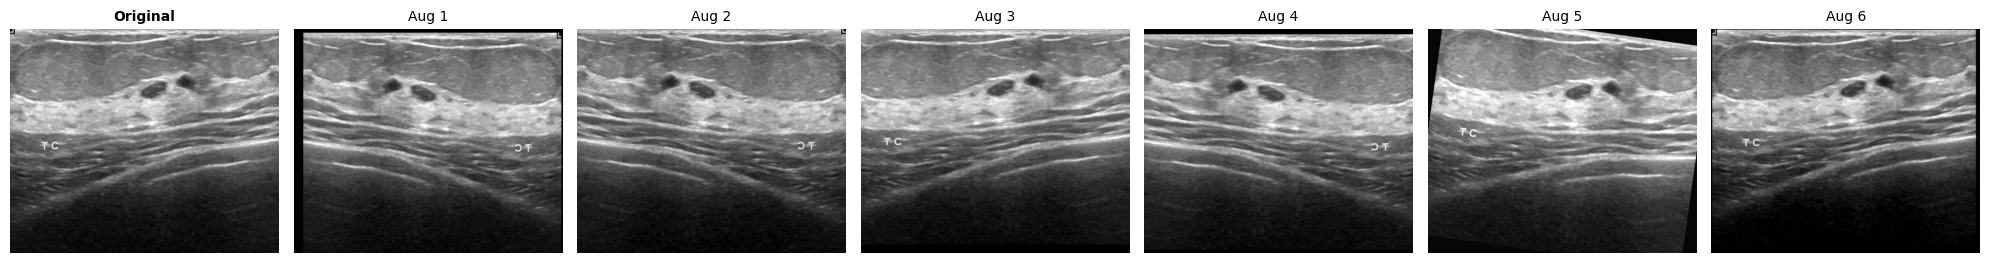

Visualización completada


In [ ]:
# ============================================================
# Solution TASK 8.2: VISUALIZATION OF AUGMENTATIONS
# ============================================================
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load example image
sample_img_path = df_train.iloc[0]['image_path']
sample_img = cv2.imread(sample_img_path)
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

# Create figure
fig, axes = plt.subplots(1, 7, figsize=(20, 4))

# Original image
axes[0].imshow(sample_img)
axes[0].set_title("Original", fontsize=10, fontweight='bold')
axes[0].axis('off')

# 6 augmented versions
for i in range(1, 7):
    augmented = train_augment(image=sample_img, mask=np.zeros((sample_img.shape[0], sample_img.shape[1]), dtype=np.uint8))
    aug_img = augmented['image'].permute(1, 2, 0).numpy()
    # Denormalize to visualize
    aug_img = aug_img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    aug_img = np.clip(aug_img, 0, 1)

    axes[i].imshow(aug_img)
    axes[i].set_title(f"Aug {i}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("Visualization completed")

## Block 8.3: Repeating an Experiment Fairly
### Why reinitialize the model instead of continuing training

`model_aug = smp.Unet(...)` creates a **brand new** model from scratch, it doesn't continue training the `model` from Practice 7. This is not an oversight: if you kept training the already-converged baseline model, you couldn't attribute any Dice improvement to the augmentation — it could simply be because the model had trained for more epochs in total.

> **Key idea:** for the Baseline vs Augmented comparison to mean something, both models must start from the same starting situation (freshly initialized architecture) and differ in **only one thing**: the data they see during training.

### Control variable: change one thing, not two

This is the same principle as a controlled experiment in any experimental science:

| Element | Baseline (P7) | Augmented (P8) | Does it change? |
|----------|----------------|-------------------|-----------|
| Architecture (`smp.Unet(...)`) | ResNet34 + decoder | ResNet34 + decoder | No |
| `NUM_EPOCHS` | The same value | The same value | No |
| Optimizer and `lr` | `Adam`, `lr=1e-4` | `Adam`, `lr=1e-4` | No |
| Loss function | `DiceBCELoss` | `DiceBCELoss` | No |
| Training data | Without augmentation | With `train_augment` | **Yes — the only variable** |

If you also changed the number of epochs or the learning rate at the same time as adding augmentation, and the Dice improves, you wouldn't know whether it improved because of the augmentation or the other change. An experiment with two variables at once doesn't allow drawing conclusions about either of them.

### The real risk of "reusing the P7 code"

The task instruction literally says "copy the P7 training code and modify only the DataLoader". That copy-paste is exactly where the most common bug of this practice sneaks in: if you forget to rename a variable, you silently overwrite the baseline results.

| Original variable (P7) | New variable (P8) | If you forget to rename... |
|---|---|---|
| `model` | `model_aug` | You keep training/evaluating the baseline model, not a new one |
| `optimizer` | `optimizer_aug` | The optimizer stays linked to the baseline model parameters |
| `train_loader` | `train_loader_aug` | You train again without augmentation, even though you think it has it |
| `train_losses`, `val_losses`, `train_dices`, `val_dices` | `..._aug` | **You overwrite the baseline lists** — in Task 8.4 you won't be able to compare anything, because baseline and augmented will be the same list |

> **Question to think about:** if in Task 8.4 your "Baseline vs Augmented" plot shows two identical lines, which variable from the table above would you first suspect wasn't renamed?

### A single run is not definitive proof

In Block 7.3 we saw that Loss and Dice can diverge (the "deceptive plateau"). The same applies here: training each configuration once gives you one data point, not statistical certainty. Small differences in the final Dice between baseline and augmented can be partly due to normal training variability (random weight initialization, batch order), not only to the augmentation itself. This doesn't invalidate the experiment — you just have to take it into account when interpreting a small difference as "augmentation won" or "augmentation lost".

### Quick summary

| Concept | Main idea |
|----------|-----------------|
| Reinitialize the model | Prevents the improvement from being due to "more total epochs" instead of the augmentation |
| Control variable | Everything equal between baseline and augmented except the training data |
| Risk of copying code | Forgetting to rename variables silently overwrites the baseline results |
| A single run | Small differences can be normal variability, not only the augmentation effect |

## Task 8.3: Re-training with Augmentation
Now we're going to re-train the model using the new DataLoader with augmentation.

### Instructions:
1. Create a new `BUSIDataset` (that allows transformations) using `train_augment` instead of the base transform
2. Create a new `DataLoader` for train (the val one can stay the same)
3. Re-initialize the U-Net model (to start from scratch)
4. Train for `NUM_EPOCHS` epochs (use the same training code from P7)
5. Save the metrics: `train_losses_aug`, `val_losses_aug`, `train_dices_aug`, `val_dices_aug`
6. Apply the same checkpointing pattern as in P7, but with `model_aug`: save the weights locally every time the Val Dice improves, and when the loop finishes also save the final checkpoint (weights + history) in Google Drive — same `CHECKPOINT_DIR` as P7, but with a different file (for example `augmented_checkpoint.pth`) so as not to overwrite the baseline one. First check whether that checkpoint already exists in Drive: if so, load it and don't retrain.

> **Hint**: You can copy the P7 training code and modify only the DataLoader

In [ ]:
# ============================================================
# SOLUTION TASK 8.3: RE-TRAINING WITH AUGMENTATION
# ============================================================
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

DRIVE_CHECKPOINT_PATH_AUG = CHECKPOINT_DIR / 'augmented_checkpoint.pth'

# 1. Create new Dataset with augmentation
train_dataset_aug = BUSIDataset(train_df, transform=train_augment)
train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

# 2. Re-initialize model
model_aug = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)
model_aug = model_aug.to(DEVICE)

# 3. Optimizer
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-4)

# 4. Train
train_losses_aug = []
val_losses_aug = []
train_dices_aug = []
val_dices_aug = []

if DRIVE_CHECKPOINT_PATH_AUG.exists():
    # This model was already trained in a previous session: load it instead of retraining
    print(f"Checkpoint found in Google Drive: {DRIVE_CHECKPOINT_PATH_AUG}")
    print("Loading the best augmented model from a previous session (no need to retrain)...")
    checkpoint = torch.load(DRIVE_CHECKPOINT_PATH_AUG, map_location=DEVICE)
    model_aug.load_state_dict(checkpoint['model_state_dict'])
    train_losses_aug = checkpoint['train_losses']
    val_losses_aug = checkpoint['val_losses']
    train_dices_aug = checkpoint['train_dices']
    val_dices_aug = checkpoint['val_dices']
    best_val_dice_aug = checkpoint['best_val_dice']
    print(f"Model loaded. Best Val Dice: {best_val_dice_aug:.4f}")

else:
    best_val_dice_aug = -1
    BEST_MODEL_PATH_AUG = 'best_model_augmented.pth'  # local checkpoint, only for this session

    print("Training with augmentation...")
    print(f"Epochs: {NUM_EPOCHS}")
    print("="*60)

    for epoch in range(NUM_EPOCHS):
        # Training Phase
        model_aug.train()
        epoch_train_loss = 0
        epoch_train_dice = 0

        train_bar = tqdm(train_loader_aug, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False)

        for images, masks in train_bar:
            images, masks = images.to(DEVICE), masks.to(DEVICE)

            optimizer_aug.zero_grad()
            logits = model_aug(images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer_aug.step()

            epoch_train_loss += loss.item()

            # Compute Dice
            with torch.no_grad():
                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).float()
                intersection = (preds * masks).sum()
                union = preds.sum() + masks.sum()
                dice = (2. * intersection + 1e-6) / (union + 1e-6)
                epoch_train_dice += dice.item()

            train_bar.set_postfix({'loss': f'{loss.item():.4f}', 'dice': f'{dice.item():.4f}'})

        epoch_train_loss /= len(train_loader_aug)
        epoch_train_dice /= len(train_loader_aug)

        # Validation Phase
        model_aug.eval()
        epoch_val_loss = 0
        epoch_val_dice = 0

        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]", leave=False)

        with torch.no_grad():
            for images, masks in val_bar:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                logits = model_aug(images)
                loss = criterion(logits, masks)
                epoch_val_loss += loss.item()

                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).float()
                intersection = (preds * masks).sum()
                union = preds.sum() + masks.sum()
                dice = (2. * intersection + 1e-6) / (union + 1e-6)
                epoch_val_dice += dice.item()

                val_bar.set_postfix({'loss': f'{loss.item():.4f}', 'dice': f'{dice.item():.4f}'})

        epoch_val_loss /= len(val_loader)
        epoch_val_dice /= len(val_loader)

        train_losses_aug.append(epoch_train_loss)
        val_losses_aug.append(epoch_val_loss)
        train_dices_aug.append(epoch_train_dice)
        val_dices_aug.append(epoch_val_dice)

        # Save local checkpoint if it's the best model so far (according to Val Dice)
        is_best = epoch_val_dice > best_val_dice_aug
        if is_best:
            best_val_dice_aug = epoch_val_dice
            torch.save(model_aug.state_dict(), BEST_MODEL_PATH_AUG)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
        print(f"   Train - Loss: {epoch_train_loss:.4f} | Dice: {epoch_train_dice:.4f}")
        print(f"   Val   - Loss: {epoch_val_loss:.4f} | Dice: {epoch_val_dice:.4f}")
        if is_best:
            print(f"   -> New best model saved ({BEST_MODEL_PATH_AUG})")
        print("-"*60)

    # Restore the best model weights (not the last epoch's)
    model_aug.load_state_dict(torch.load(BEST_MODEL_PATH_AUG))

    # Save to Google Drive so we don't have to retrain in future sessions
    torch.save({
        'model_state_dict': model_aug.state_dict(),
        'best_val_dice': best_val_dice_aug,
        'train_losses': train_losses_aug,
        'val_losses': val_losses_aug,
        'train_dices': train_dices_aug,
        'val_dices': val_dices_aug,
    }, DRIVE_CHECKPOINT_PATH_AUG)
    print(f"\nBest model weights restored in 'model_aug' (Val Dice: {best_val_dice_aug:.4f})")
    print(f"Checkpoint saved in Google Drive: {DRIVE_CHECKPOINT_PATH_AUG}")

print("Training with augmentation completed")
print(f"Best Dice Score in validation: {max(val_dices_aug):.4f} (Epoch {val_dices_aug.index(max(val_dices_aug)) + 1})")

Checkpoint encontrado en Google Drive: /content/drive/MyDrive/PIM_Challenge/checkpoints/augmented_checkpoint.pth
Cargando el mejor modelo augmented de una sesión anterior (no hace falta reentrenar)...
Modelo cargado. Mejor Val Dice: 0.7626
Entrenamiento con augmentation completado
Mejor Dice Score en validación: 0.7626 (Epoch 10)


## Block 8.4: Reading a Training Curves Comparison
### Four panels, four different questions

The 2x2 figure is not simply "four pretty plots" — each panel answers a different question, and you have to read them in that order:

| Panel | Question it answers |
|-------|--------------------------|
| Train Loss | Is the model still learning on the data it sees? |
| Train Dice | How well does each model fit the training data? |
| Val Loss | Which one generalizes better according to the loss function? |
| Val Dice | Which one generalizes better according to the metric that really matters? |

### The metric that really decides: Val Dice

Of the four panels, **Val Dice** is the one most similar to what Kaggle will score on the test set (which you haven't seen). Train Loss and Train Dice only tell you how well each model memorizes the data it already knows — a high value there guarantees nothing about new images.

> **Key idea:** if you had to keep a single number to decide which model to upload to Kaggle, it would be the best Val Dice, not the best Train Dice.

### Don't look only at the final value: look at the train-val gap

Remember Block 8.1: the symptom of overfitting is that train and val separate. That's why the most informative comparison is not "what final Val Dice does each model have?", but "what distance is there between Train Dice and Val Dice in each one?":

| Model | High Train Dice and low Val Dice (large gap) | Similar Train Dice and Val Dice (small gap) |
|--------|----------------------------------------------------|-------------------------------------------------------|
| Interpretation | Overfitting: memorizes train, doesn't generalize | Generalizes better, even if its absolute Dice is somewhat lower |

It's perfectly possible that the Augmented model has a **lower** Train Dice than the Baseline (because it trains with harder and more varied data) and still be the model that generalizes best, if its train-val gap is smaller.

### Comparable axes: why fix the same limits

The instructions ask for `axes[...].set_ylim(0, 1)` on the Dice panels. This isn't aesthetic: if each subplot auto-adjusted its own Y-axis range, two curves with real differences could look visually identical (or the opposite, minimal differences could look huge) just because of matplotlib's automatic zoom. To compare honestly, both curves of the same panel must share the scale.

### A small difference is not always a victory

As we saw in Block 8.3, a single run has inherent variability. If the Augmented's final Val Dice is, for example, 0.76 vs 0.74 for the Baseline, that 2-point difference can be due as much to the augmentation as to the randomness of that specific run. A consistent difference visible over several epochs (not only at the last point) is a more reliable signal than comparing a single final value.

> **Question to think about:** if when you finish you see that the Augmented has a worse Val Dice than the Baseline with the same number of epochs, would you immediately discard the augmentation, or is there something in Block 8.1 (about the added difficulty of training with more variability) that suggests reviewing before concluding anything?

### Quick summary

| Concept | Main idea |
|----------|-----------------|
| Four panels | Each answers a different question; they're not interchangeable |
| Val Dice | The metric most similar to what Kaggle evaluates |
| Train-val gap | More informative than the isolated final value; small gap = better generalization |
| Shared axes | `set_ylim` equal on both curves avoids visually misleading comparisons |
| Small difference | Can be single-run variability, not a solid conclusion |

## Task 8.4: Baseline vs Augmented Comparison
It's time to compare the results. Let's visualize the training curves of both models side by side.

### Instructions:
1. Create a 2x2 figure with:
   - Plot 1: Train Loss (Baseline vs Augmented)
   - Plot 2: Val Loss (Baseline vs Augmented)
   - Plot 3: Train Dice (Baseline vs Augmented)
   - Plot 4: Val Dice (Baseline vs Augmented)
2. Use different colors for each model
3. Add legends, titles and grid

> **CHECKPOINT P8.2:** Show the professor the comparison figure and explain the observed differences

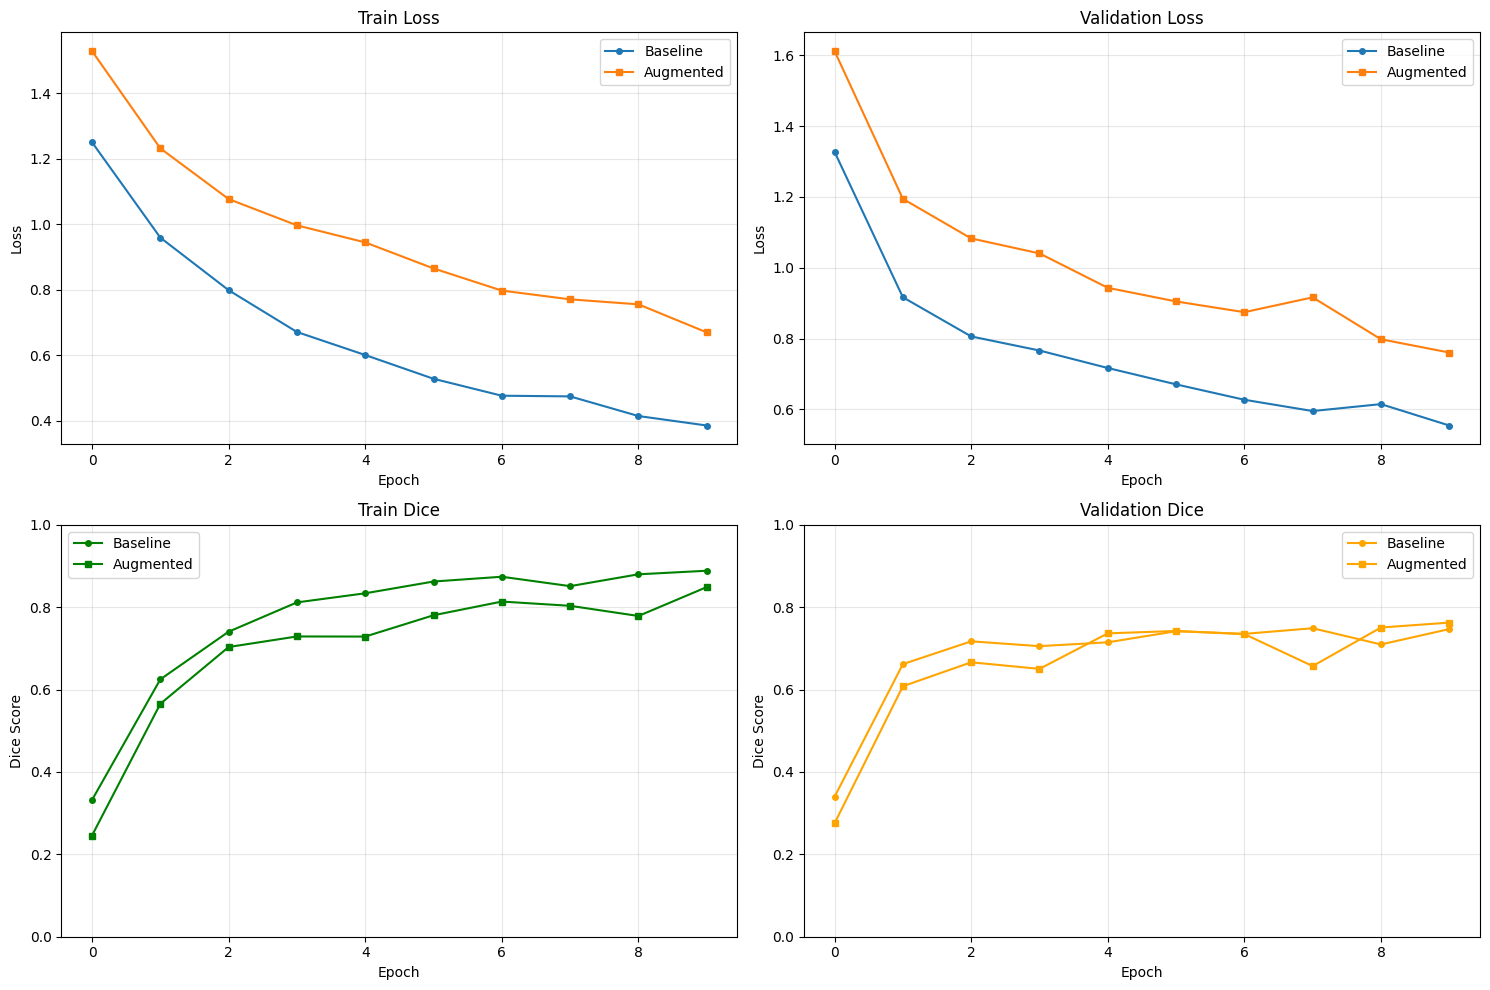


RESUMEN COMPARATIVO
Baseline - Mejor Val Dice: 0.7490 (Epoch 8)
Augmented - Mejor Val Dice: 0.7626 (Epoch 10)
Mejora: +0.0136
¡La augmentation mejoró el modelo!


In [ ]:
# ============================================================
# Solution TASK 8.4: BASELINE VS AUGMENTED COMPARISON
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Train Loss
axes[0, 0].plot(train_losses, label='Baseline', marker='o', markersize=4)
axes[0, 0].plot(train_losses_aug, label='Augmented', marker='s', markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Train Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Val Loss
axes[0, 1].plot(val_losses, label='Baseline', marker='o', markersize=4)
axes[0, 1].plot(val_losses_aug, label='Augmented', marker='s', markersize=4)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Validation Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Train Dice
axes[1, 0].plot(train_dices, label='Baseline', marker='o', markersize=4, color='green')
axes[1, 0].plot(train_dices_aug, label='Augmented', marker='s', markersize=4, color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Dice Score')
axes[1, 0].set_title('Train Dice')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(0, 1)

# Plot 4: Val Dice
axes[1, 1].plot(val_dices, label='Baseline', marker='o', markersize=4, color='orange')
axes[1, 1].plot(val_dices_aug, label='Augmented', marker='s', markersize=4, color='orange')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Dice Score')
axes[1, 1].set_title('Validation Dice')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*60)
print("COMPARATIVE SUMMARY")
print("="*60)
print(f"Baseline - Best Val Dice: {max(val_dices):.4f} (Epoch {val_dices.index(max(val_dices)) + 1})")
print(f"Augmented - Best Val Dice: {max(val_dices_aug):.4f} (Epoch {val_dices_aug.index(max(val_dices_aug)) + 1})")
print(f"Improvement: {max(val_dices_aug) - max(val_dices):+.4f}")

if max(val_dices_aug) > max(val_dices):
    print("The augmentation improved the model!")
else:
    print("The augmentation did not improve the model. Try adjusting the parameters.")



# Why can augmentation give worse results? (notes, updated after Drive checkpointing)

In a previous run something like this was seen:
- **Baseline**: 0.7436 (10 epochs)
- **Augmented**: 0.4527 (10 epochs)

There are **3 main reasons** that explain it in general:

### **1. 10 epochs is too few to compare**
With augmentation, the model "sees" more varied data and needs **more time to converge**. It's as if it were learning from a more complex book: it needs more classes.

### **2. Statistical variability**
The baseline curve indicates there is **natural variability** in the results due to:
- Different train/val split (randomness)
- Different weight initialization
- Different random seed

### **3. Augmentation adds noise**
Each augmented image is a "distorted version" of the original. The model needs more epochs to learn the real patterns behind the noise.

---

## Solution: Extended training

Let's do a fair comparison with **30 epochs** and **lower learning rate**:

## Final comparison (with the current checkpoints in Drive)

| Model | Epochs | LR | Best Val Dice |
|--------|--------|-----|----------------|
| **Baseline** | 10 | 1e-4 | 0.7490 (epoch 8) |
| **Augmented (v1)** | 10 | 1e-4 | 0.7626 (epoch 10) |
| **Augmented (v2)** | 30 | 3e-5 | 0.7539 (epoch 25) |

**Result**: with the checkpoints currently in Drive, augmented v1 already beat the baseline even with only 10 epochs (+0.0136) — the one-off run that gave 0.4527 was not representative. The extended version (v2) also beats the baseline (+0.0050), but doesn't improve on v1: with such a small dataset, lowering the learning rate and lengthening training doesn't guarantee a better result, only a more stable one.

---

## Key lesson for the students

> **"In Deep Learning, you can't compare models with different training times. A model with augmentation needs more epochs to converge because it is learning from more varied data — but that doesn't mean more epochs always give a better result. Variability between runs is real, and conclusions must not be drawn from a single run."**

In [ ]:
# ============================================================
# SOLUTION TASK 8.3: RE-TRAINING WITH AUGMENTATION II
# ============================================================
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

DRIVE_CHECKPOINT_PATH_AUG_V2 = CHECKPOINT_DIR / 'augmented_extended_checkpoint.pth'

# 1. Create new Dataset with augmentation
train_dataset_aug = BUSIDataset(train_df, transform=train_augment)
train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

# 2. Re-initialize model
model_aug = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)
model_aug = model_aug.to(DEVICE)

# 3. Optimizer, lower learning rate for stability
#optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-4)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=3e-5)
# more epochs
NUM_EPOCHS = 30


# 4. Train
train_losses_aug = []
val_losses_aug = []
train_dices_aug = []
val_dices_aug = []

if DRIVE_CHECKPOINT_PATH_AUG_V2.exists():
    # This extended version was already trained in a previous session: load it instead of retraining
    print(f"Checkpoint found in Google Drive: {DRIVE_CHECKPOINT_PATH_AUG_V2}")
    print("Loading the best model from a previous session (no need to retrain)...")
    checkpoint = torch.load(DRIVE_CHECKPOINT_PATH_AUG_V2, map_location=DEVICE)
    model_aug.load_state_dict(checkpoint['model_state_dict'])
    train_losses_aug = checkpoint['train_losses']
    val_losses_aug = checkpoint['val_losses']
    train_dices_aug = checkpoint['train_dices']
    val_dices_aug = checkpoint['val_dices']
    best_val_dice_aug = checkpoint['best_val_dice']
    print(f"Model loaded. Best Val Dice: {best_val_dice_aug:.4f}")

else:
    best_val_dice_aug = -1
    BEST_MODEL_PATH_AUG = 'best_model_augmented_v2.pth'  # local checkpoint, only for this session

    print("Training with augmentation...")
    print(f"Epochs: {NUM_EPOCHS}")
    print("="*60)

    for epoch in range(NUM_EPOCHS):
        # Training Phase
        model_aug.train()
        epoch_train_loss = 0
        epoch_train_dice = 0

        train_bar = tqdm(train_loader_aug, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False)

        for images, masks in train_bar:
            images, masks = images.to(DEVICE), masks.to(DEVICE)

            optimizer_aug.zero_grad()
            logits = model_aug(images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer_aug.step()

            epoch_train_loss += loss.item()

            # Compute Dice
            with torch.no_grad():
                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).float()
                intersection = (preds * masks).sum()
                union = preds.sum() + masks.sum()
                dice = (2. * intersection + 1e-6) / (union + 1e-6)
                epoch_train_dice += dice.item()

            train_bar.set_postfix({'loss': f'{loss.item():.4f}', 'dice': f'{dice.item():.4f}'})

        epoch_train_loss /= len(train_loader_aug)
        epoch_train_dice /= len(train_loader_aug)

        # Validation Phase
        model_aug.eval()
        epoch_val_loss = 0
        epoch_val_dice = 0

        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]", leave=False)

        with torch.no_grad():
            for images, masks in val_bar:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                logits = model_aug(images)
                loss = criterion(logits, masks)
                epoch_val_loss += loss.item()

                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).float()
                intersection = (preds * masks).sum()
                union = preds.sum() + masks.sum()
                dice = (2. * intersection + 1e-6) / (union + 1e-6)
                epoch_val_dice += dice.item()

                val_bar.set_postfix({'loss': f'{loss.item():.4f}', 'dice': f'{dice.item():.4f}'})

        epoch_val_loss /= len(val_loader)
        epoch_val_dice /= len(val_loader)

        train_losses_aug.append(epoch_train_loss)
        val_losses_aug.append(epoch_val_loss)
        train_dices_aug.append(epoch_train_dice)
        val_dices_aug.append(epoch_val_dice)

        # Save local checkpoint if it's the best model so far (according to Val Dice)
        is_best = epoch_val_dice > best_val_dice_aug
        if is_best:
            best_val_dice_aug = epoch_val_dice
            torch.save(model_aug.state_dict(), BEST_MODEL_PATH_AUG)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
        print(f"   Train - Loss: {epoch_train_loss:.4f} | Dice: {epoch_train_dice:.4f}")
        print(f"   Val   - Loss: {epoch_val_loss:.4f} | Dice: {epoch_val_dice:.4f}")
        if is_best:
            print(f"   -> New best model saved ({BEST_MODEL_PATH_AUG})")
        print("-"*60)

    # Restore the best model weights (not the last epoch's)
    model_aug.load_state_dict(torch.load(BEST_MODEL_PATH_AUG))

    # Save to Google Drive so we don't have to retrain in future sessions
    torch.save({
        'model_state_dict': model_aug.state_dict(),
        'best_val_dice': best_val_dice_aug,
        'train_losses': train_losses_aug,
        'val_losses': val_losses_aug,
        'train_dices': train_dices_aug,
        'val_dices': val_dices_aug,
    }, DRIVE_CHECKPOINT_PATH_AUG_V2)
    print(f"\nBest model weights restored in 'model_aug' (Val Dice: {best_val_dice_aug:.4f})")
    print(f"Checkpoint saved in Google Drive: {DRIVE_CHECKPOINT_PATH_AUG_V2}")

print("Training with augmentation completed")
print(f"Best Dice Score in validation: {max(val_dices_aug):.4f} (Epoch {val_dices_aug.index(max(val_dices_aug)) + 1})")

Entrenando con augmentation...
Épocas: 30


Epoch 1/30 [Train]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 1/30
   Train - Loss: 1.5134 | Dice: 0.1579
   Val   - Loss: 1.5403 | Dice: 0.1659
   -> Nuevo mejor modelo guardado (best_model_augmented_v2.pth)
------------------------------------------------------------


Epoch 2/30 [Train]:   0%|          | 0/28 [00:00<?, ?it/s]

...

Epoch 29/30 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 29/30
   Train - Loss: 0.5384 | Dice: 0.8888
   Val   - Loss: 0.6961 | Dice: 0.7510
------------------------------------------------------------


Epoch 30/30 [Train]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 30/30 [Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 30/30
   Train - Loss: 0.5155 | Dice: 0.8963
   Val   - Loss: 0.6953 | Dice: 0.7468
------------------------------------------------------------

Pesos del mejor modelo restaurados en 'model_aug' (Val Dice: 0.7539)
Checkpoint guardado en Google Drive: /content/drive/MyDrive/PIM_Challenge/checkpoints/augmented_extended_checkpoint.pth
Entrenamiento con augmentation completado
Mejor Dice Score en validación: 0.7539 (Epoch 25)


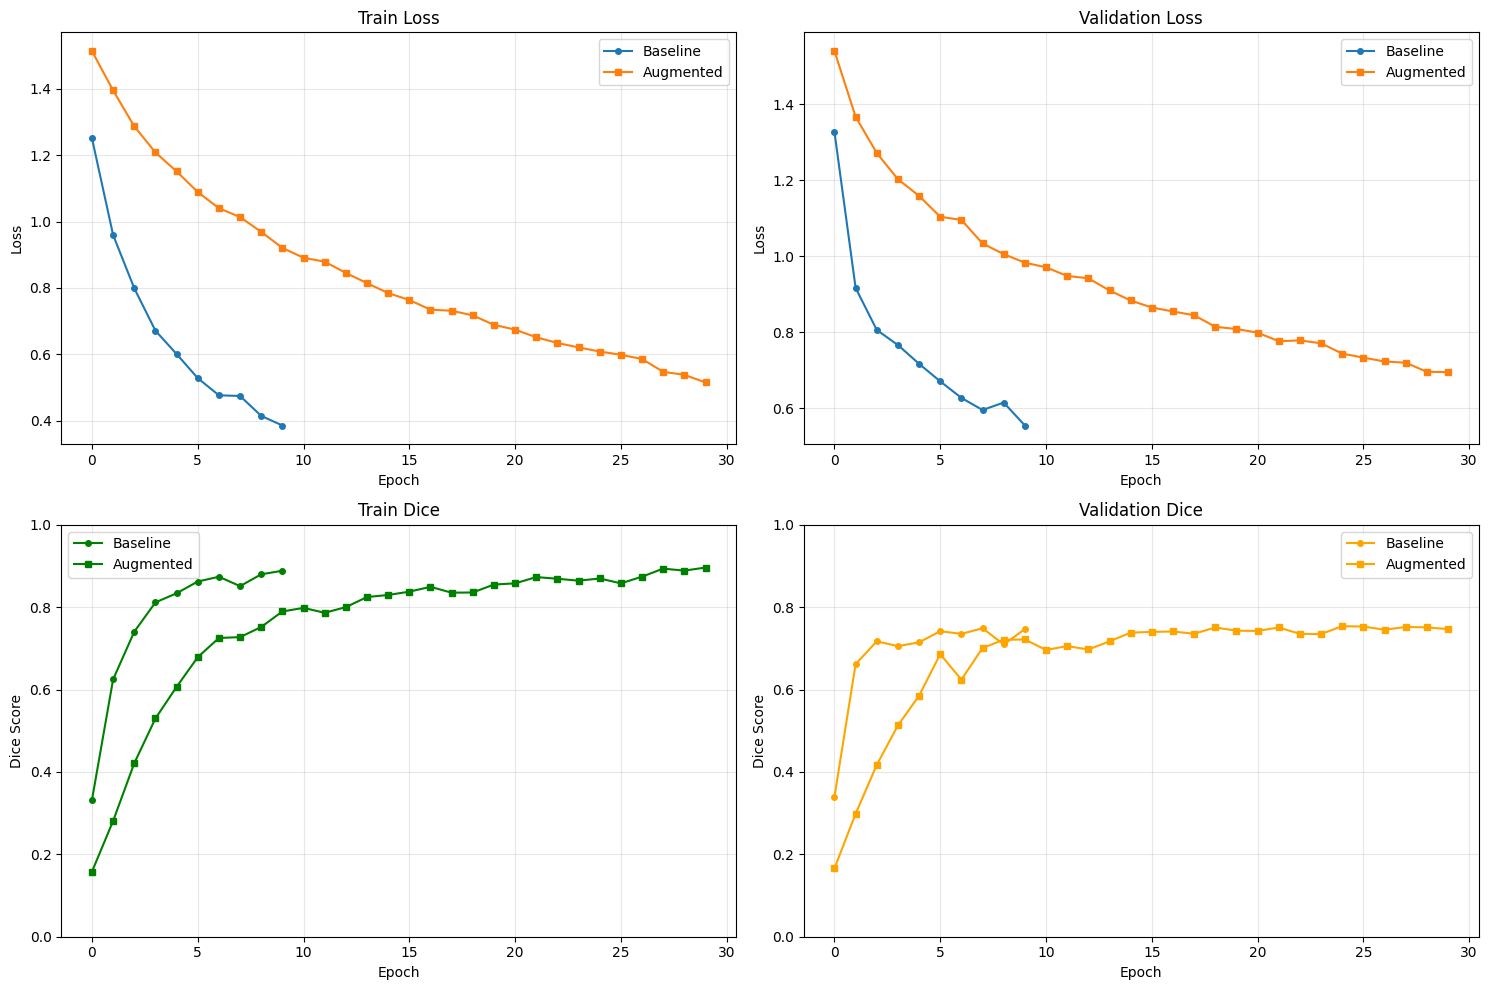


RESUMEN COMPARATIVO
Baseline - Mejor Val Dice: 0.7490 (Epoch 8)
Augmented - Mejor Val Dice: 0.7539 (Epoch 25)
Mejora: +0.0050
¡La augmentation mejoró el modelo!


In [ ]:
# ============================================================
# Solution TASK 8.4: BASELINE VS AUGMENTED COMPARISON (II)
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Train Loss
axes[0, 0].plot(train_losses, label='Baseline', marker='o', markersize=4)
axes[0, 0].plot(train_losses_aug, label='Augmented', marker='s', markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Train Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Val Loss
axes[0, 1].plot(val_losses, label='Baseline', marker='o', markersize=4)
axes[0, 1].plot(val_losses_aug, label='Augmented', marker='s', markersize=4)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Validation Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Train Dice
axes[1, 0].plot(train_dices, label='Baseline', marker='o', markersize=4, color='green')
axes[1, 0].plot(train_dices_aug, label='Augmented', marker='s', markersize=4, color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Dice Score')
axes[1, 0].set_title('Train Dice')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(0, 1)

# Plot 4: Val Dice
axes[1, 1].plot(val_dices, label='Baseline', marker='o', markersize=4, color='orange')
axes[1, 1].plot(val_dices_aug, label='Augmented', marker='s', markersize=4, color='orange')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Dice Score')
axes[1, 1].set_title('Validation Dice')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*60)
print("COMPARATIVE SUMMARY")
print("="*60)
print(f"Baseline - Best Val Dice: {max(val_dices):.4f} (Epoch {val_dices.index(max(val_dices)) + 1})")
print(f"Augmented - Best Val Dice: {max(val_dices_aug):.4f} (Epoch {val_dices_aug.index(max(val_dices_aug)) + 1})")
print(f"Improvement: {max(val_dices_aug) - max(val_dices):+.4f}")

if max(val_dices_aug) > max(val_dices):
    print("The augmentation improved the model!")
else:
    print("The augmentation did not improve the model. Try adjusting the parameters.")

## Selecting the definitive model before P9

With the three checkpoints already trained (baseline, augmented v1, extended augmented v2) and the comparison from the previous cell, we explicitly choose the best one by Val Dice **from the checkpoints saved in Drive** — it's not enough to keep using the `model` variable, which still points to the P7 baseline, nor to trust `model_aug` in memory, because the extended re-training cell reuses that same variable name and overwrites it.

In [ ]:
# ============================================================
# SELECTION OF THE DEFINITIVE MODEL (baseline vs augmented v1 vs extended augmented v2)
# ============================================================
# We compare the three checkpoints saved in Drive by their best_val_dice
# and load the winner into 'model', which is what P9 and P10 use from here on.

candidates_paths = {
    'baseline (P7)': CHECKPOINT_DIR / 'baseline_checkpoint.pth',
    'augmented v1 (P8)': CHECKPOINT_DIR / 'augmented_checkpoint.pth',
    'augmented v2 extended (P8, 30 epochs)': CHECKPOINT_DIR / 'augmented_extended_checkpoint.pth',
}

candidates = {}
for name, path in candidates_paths.items():
    if path.exists():
        ckpt = torch.load(path, map_location=DEVICE)
        candidates[name] = ckpt
        print(f"{name}: Val Dice = {ckpt['best_val_dice']:.4f}")
    else:
        print(f"{name}: not found in Drive ({path})")

best_name = max(candidates, key=lambda n: candidates[n]['best_val_dice'])
best_checkpoint = candidates[best_name]

model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1, activation=None)
model = model.to(DEVICE)
model.load_state_dict(best_checkpoint['model_state_dict'])

print(f"\nDefinitive model selected: {best_name} (Val Dice = {best_checkpoint['best_val_dice']:.4f})")
print("From here on, 'model' points to this checkpoint for the rest of the notebook (P9 and P10).")

# Practice 9: Inference, Threshold Optimization and Error Analysis
## Single session (23 Nov Group A / 25 Nov Group B)

### Session objectives:
1. Understand why the decision threshold of 0.5 is not always optimal in medicine.
2. Compute the **Optimal Threshold** by evaluating the validation set.
3. Perform a **Qualitative Error Analysis** (False Positives and False Negatives).
4. Generate the **Final Submission** for Kaggle.

###  Clinical Context: The FP vs FN dilemma
In breast cancer detection:
*   **False Negative (FN):** Saying there is no tumor when there is one. (Serious: treatment delay).
*   **False Positive (FP):** Saying there is a tumor when there isn't. (Anxiety, unnecessary biopsies).

Our model must find the perfect balance. Today we're going to look for it.

> **CHECKPOINT P9:** Show the professor:
> 1. Threshold vs Dice Score plot with the optimal point marked.
> 2. Visualization of 5 critical cases (including at least 1 "normal" image and 1 serious error).

## Block 9.1: The Threshold as a Hyperparameter
### 0.5 was never an informed decision

Since Practice 7 you have used `probs > 0.5` to convert probabilities into a binary mask. That 0.5 didn't come from any analysis of your data: it's simply the midpoint of the `sigmoid()` range (which goes from 0 to 1), the most "neutral" possible default option. Nothing guarantees it's the best cut for this specific dataset.

> **Key idea:** the threshold is one more hyperparameter of your system, just like `lr` or `NUM_EPOCHS` — you simply had left it fixed until now without questioning it.

### Why the threshold is not free: precision vs recall

Remember the clinical dilemma from the introduction of this practice: a False Negative (not detecting a real tumor) and a False Positive (detecting a tumor that doesn't exist) don't have the same cost. The threshold directly controls that balance:

| Threshold | Effect on the mask | Consequence |
|-----------|------------------------|----------------|
| Lower (e.g. 0.3) | The model marks "tumor" with less evidence | Fewer False Negatives, more False Positives |
| Higher (e.g. 0.7) | The model demands more confidence to mark "tumor" | Fewer False Positives, more False Negatives |

The Dice Score you're going to maximize is an average that weights precision and recall equally — it doesn't distinguish whether you err by FP or by FN. Maximizing Dice gives you the best *statistical* balance, but not necessarily the best *clinical* balance (where an FN is usually more serious than an FP).

> **Question to think about:** if you were the clinical responsible for this system and had to choose between the threshold that maximizes Dice and a slightly different one that reduces False Negatives at the cost of some Dice, which would you choose? Why does the exercise, even so, ask you to maximize Dice?

### Why it is searched on validation, not on train or test

This is exactly the same principle of Practices 7 and 8 applied to a new hyperparameter:

| Set | Why NOT use it to choose the threshold? |
|----------|-------------------------------------------------|
| Train | The model already saw this data when training; the threshold would be tuned to the specific noise of those images |
| Test | It has no masks — you can't compute Dice there. And even if it had them, choosing the threshold by looking at test would be "cheating": you'd be tuning a hyperparameter with the same data you're later evaluated on |
| Val | Data the model didn't use to adjust weights, and you do have masks to measure Dice — the fair choice |

### Why you don't need to retrain to test each threshold

Unlike changing `lr` or adding augmentation (which force you to train the whole model again), the threshold is applied **after** the model has already generated its probabilities. The model weights don't change between one threshold and another — only where you cut those probabilities to decide 0 or 1 changes. That's why you can sweep 17 threshold values (0.1 to 0.9 in steps of 0.05) evaluating the `val_loader` once for each, with no training cost at all.

### How to interpret the Threshold vs Dice curve

The typical shape of this curve is a bell: low Dice at the extremes (very low thresholds generate too many False Positives; very high ones, too many False Negatives) and a maximum at some intermediate point.

| Curve shape | Interpretation |
|----------------------|-------------------|
| Marked and narrow peak | The threshold matters a lot; choosing badly costs Dice noticeably |
| Flat curve in the central zone | The model is robust to the exact threshold; several nearby values give a similar Dice |

### Quick summary

| Concept | Main idea |
|----------|-----------------|
| Threshold | One more hyperparameter, not a fixed constant |
| Precision vs recall | Low threshold → fewer FN, more FP; high threshold → the opposite |
| Where to search | In validation: train biases the tuning, test would invalidate the evaluation |
| Search cost | None in training — the model doesn't change, only the decision cut |
| Curve shape | A marked peak means the threshold matters; a flat curve means the model is robust over a range of values |

## Task 9.1: Search for the Optimal Threshold
So far we have used `threshold = 0.5` to binarize the probabilities. But is it really the best value for our dataset?

### Instructions:
1. Put the model in evaluation mode (`model.eval()`).
2. Iterate over the `val_loader` (without computing gradients).
3. For each batch, get the probabilities (`torch.sigmoid(logits)`).
4. Test a range of thresholds from **0.1 to 0.9** (in steps of 0.05).
5. For each threshold, compute the **average Dice Score** over the whole validation set.
6. Plot: **X axis** = Threshold, **Y axis** = Dice Score.
7. Identify and save the `best_threshold` that maximizes the Dice.

> **Hint:** Don't modify the model weights. You are only evaluating how the metric changes when the decision cut changes.

Evaluando thresholds en el conjunto de validación...
   Threshold 0.10 -> Dice: 0.6401
   Threshold 0.15 -> Dice: 0.6919
   Threshold 0.20 -> Dice: 0.7090
   Threshold 0.25 -> Dice: 0.7274
   Threshold 0.30 -> Dice: 0.7363
   Threshold 0.35 -> Dice: 0.7409
   Threshold 0.40 -> Dice: 0.7443
   Threshold 0.45 -> Dice: 0.7469
   Threshold 0.50 -> Dice: 0.7490
   Threshold 0.55 -> Dice: 0.7505
   Threshold 0.60 -> Dice: 0.7516
   Threshold 0.65 -> Dice: 0.7523
   Threshold 0.70 -> Dice: 0.7523
   Threshold 0.75 -> Dice: 0.7514
   Threshold 0.80 -> Dice: 0.7497
   Threshold 0.85 -> Dice: 0.7457
   Threshold 0.90 -> Dice: 0.7359


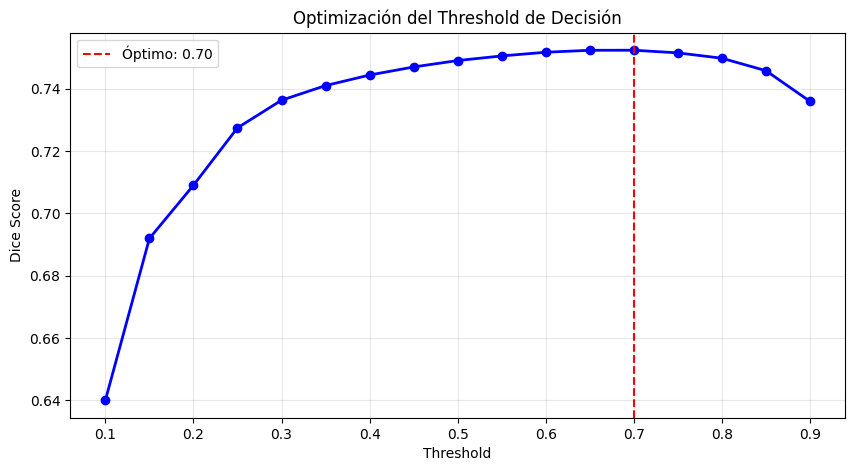


Mejor Threshold encontrado: 0.70 con Dice: 0.7523


In [ ]:
# ============================================================
# SOLUTION TASK 9.1: SEARCH FOR THE OPTIMAL THRESHOLD
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.arange(0.1, 0.95, 0.05)
val_dices_per_threshold = []

print("Evaluating thresholds on the validation set...")
model.eval()

for threshold in thresholds:
    epoch_dice = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            intersection = (preds * masks).sum()
            union = preds.sum() + masks.sum()
            dice = (2. * intersection + 1e-6) / (union + 1e-6)
            epoch_dice += dice.item()

    avg_dice = epoch_dice / len(val_loader)
    val_dices_per_threshold.append(avg_dice)
    print(f"   Threshold {threshold:.2f} -> Dice: {avg_dice:.4f}")

# Find the best one
best_idx = np.argmax(val_dices_per_threshold)
best_threshold = thresholds[best_idx]
max_dice = val_dices_per_threshold[best_idx]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(thresholds, val_dices_per_threshold, marker='o', color='b', linewidth=2)
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Optimal: {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Dice Score')
plt.title('Threshold Decision Optimization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nBest Threshold found: {best_threshold:.2f} with Dice: {max_dice:.4f}")

## Block 9.2: Reading the Errors of a Segmentation Model
### Why an average is not enough

An average Dice of 0.80 on validation can be composed of many different ways: 100 images with Dice 0.80 each, or 90 images with Dice 0.95 and 10 images with Dice 0.05. The average doesn't distinguish these two scenarios, but clinically they are radically different — the second case means there is a subgroup of patients where the model fails completely, hidden behind a good overall average.

### TP, TN, FP and FN at pixel level

So far you have computed Dice and IoU as formulas over sets of pixels, without explicitly naming their four components. In segmentation, each pixel of the predicted mask falls into one of these four categories when compared with the ground truth:

| | GT = tumor | GT = background |
|---|---|---|
| **Prediction = tumor** | TP (hit) | FP (false alarm) |
| **Prediction = background** | FN (miss, doesn't detect it) | TN (hit) |

In a **normal** image (real mask completely empty, without any tumor pixel), it is mathematically impossible to have TP or FN — there is no tumor to get right or to miss. The only possible results are TN (all the background correctly ignored) or FP (the model "hallucinates" a tumor where none exists). That's why Case 1 of this task (a normal image) is the most direct and clean check of whether your model generates False Positives.

### Why choose the cases on purpose, and not at random

The BUSI dataset is imbalanced (437 benign, 210 malignant, 133 normal). If you chose 5 purely random images from `val_df`, the most likely outcome is that all 5 are `benign` — the majority class — and you'd never see how the model behaves on `normal` or `malignant` images. It's the same problem as the split in Block 7.1, now applied to visual inspection: a random sampling blind to the minority classes teaches you nothing about them. That's why the task explicitly asks for one case of each class, and not "5 random images".

### How to find the "catastrophic failures" without relying on luck

For Cases 4 and 5, the instruction allows searching "by iterating" instead of at random. The systematic way to do it is: compute the individual Dice of each image of `val_df` (not the average, one per image),
and sort from lowest to highest. The images with the lowest Dice are, by definition, the ones where the model fails the most — finding them by brute force is much more reliable than trusting them to show up by chance in a small random sample.

### What to look at in the overlay

The overlay (prediction in red on the original image) is where you see the *type* of error, not only whether there was an error:

| Visual pattern | Type of error | Effect on Dice |
|-----------------|-----------------|-------------------|
| Red falls short of the real tumor contour | Under-segmentation (FN on the border) | Reduces Dice |
| Red extends beyond the real contour | Over-segmentation (FP on the border) | Reduces Dice |
| Red appears on healthy tissue with no tumor nearby | "Hallucinated" False Positive | Reduces Dice and is clinically serious |
| No red where there is a tumor | Complete False Negative | The most clinically serious error |

### From the technical to the clinical

The checkpoint doesn't only ask to identify TP/TN/FP/FN — it asks to explain **what each type of error means clinically**. It's not the same to say "there are FP pixels on the upper border" as to say "the model would mark a healthy area as suspicious, which would lead to unnecessary tests or biopsies in this patient". The second sentence is the one that connects with the FP/FN dilemma from the introduction of this practice.

### Quick summary

| Concept | Main idea |
|----------|-----------------|
| Average vs individual cases | A good average Dice can hide serious failures in specific subgroups |
| TP/TN/FP/FN per pixel | In normal images only TN or FP are possible — never TP or FN |
| Deliberate selection | Random sampling on imbalanced data hides the minority classes |
| Searching for failures | Sort by individual Dice, don't rely on chance |
| Overlay | The visual pattern (missing, extra, or appearing where it shouldn't) indicates the type of error |
| Clinical explanation | Translate TP/FP/FN into real consequences for the patient |

## Task 9.2: Qualitative Error Analysis
The numerical metrics don't tell the whole story. A Dice of 0.80 can hide serious errors in clinically relevant cases. Let's visualize **where** the model is failing.

### Instructions:
1. Select manually (or randomly) 5 images from `val_df` that represent:
   * **Case 1:** An image of class **"normal"** (to see if there are False Positives).
   * **Case 2:** An image of class **"benign"** with a small tumor.
   * **Case 3:** An image of class **"malignant"** with irregular borders.
   * **Cases 4 and 5:** Two images where the model has failed catastrophically (you can search for them by iterating if you want, or use random ones).
2. For each one, generate a figure with 4 columns:
   * **Original**
   * **Ground Truth (Real Mask)**
   * **Prediction** (using your `best_threshold`)
   * **Overlay** (Prediction in red on the Original)
3. Add a title to each image indicating its class and whether it's TP, TN, FP or FN.

> **CHECKPOINT P9.1:** Show the professor the 5 images and explain clinically what is happening in the errors.

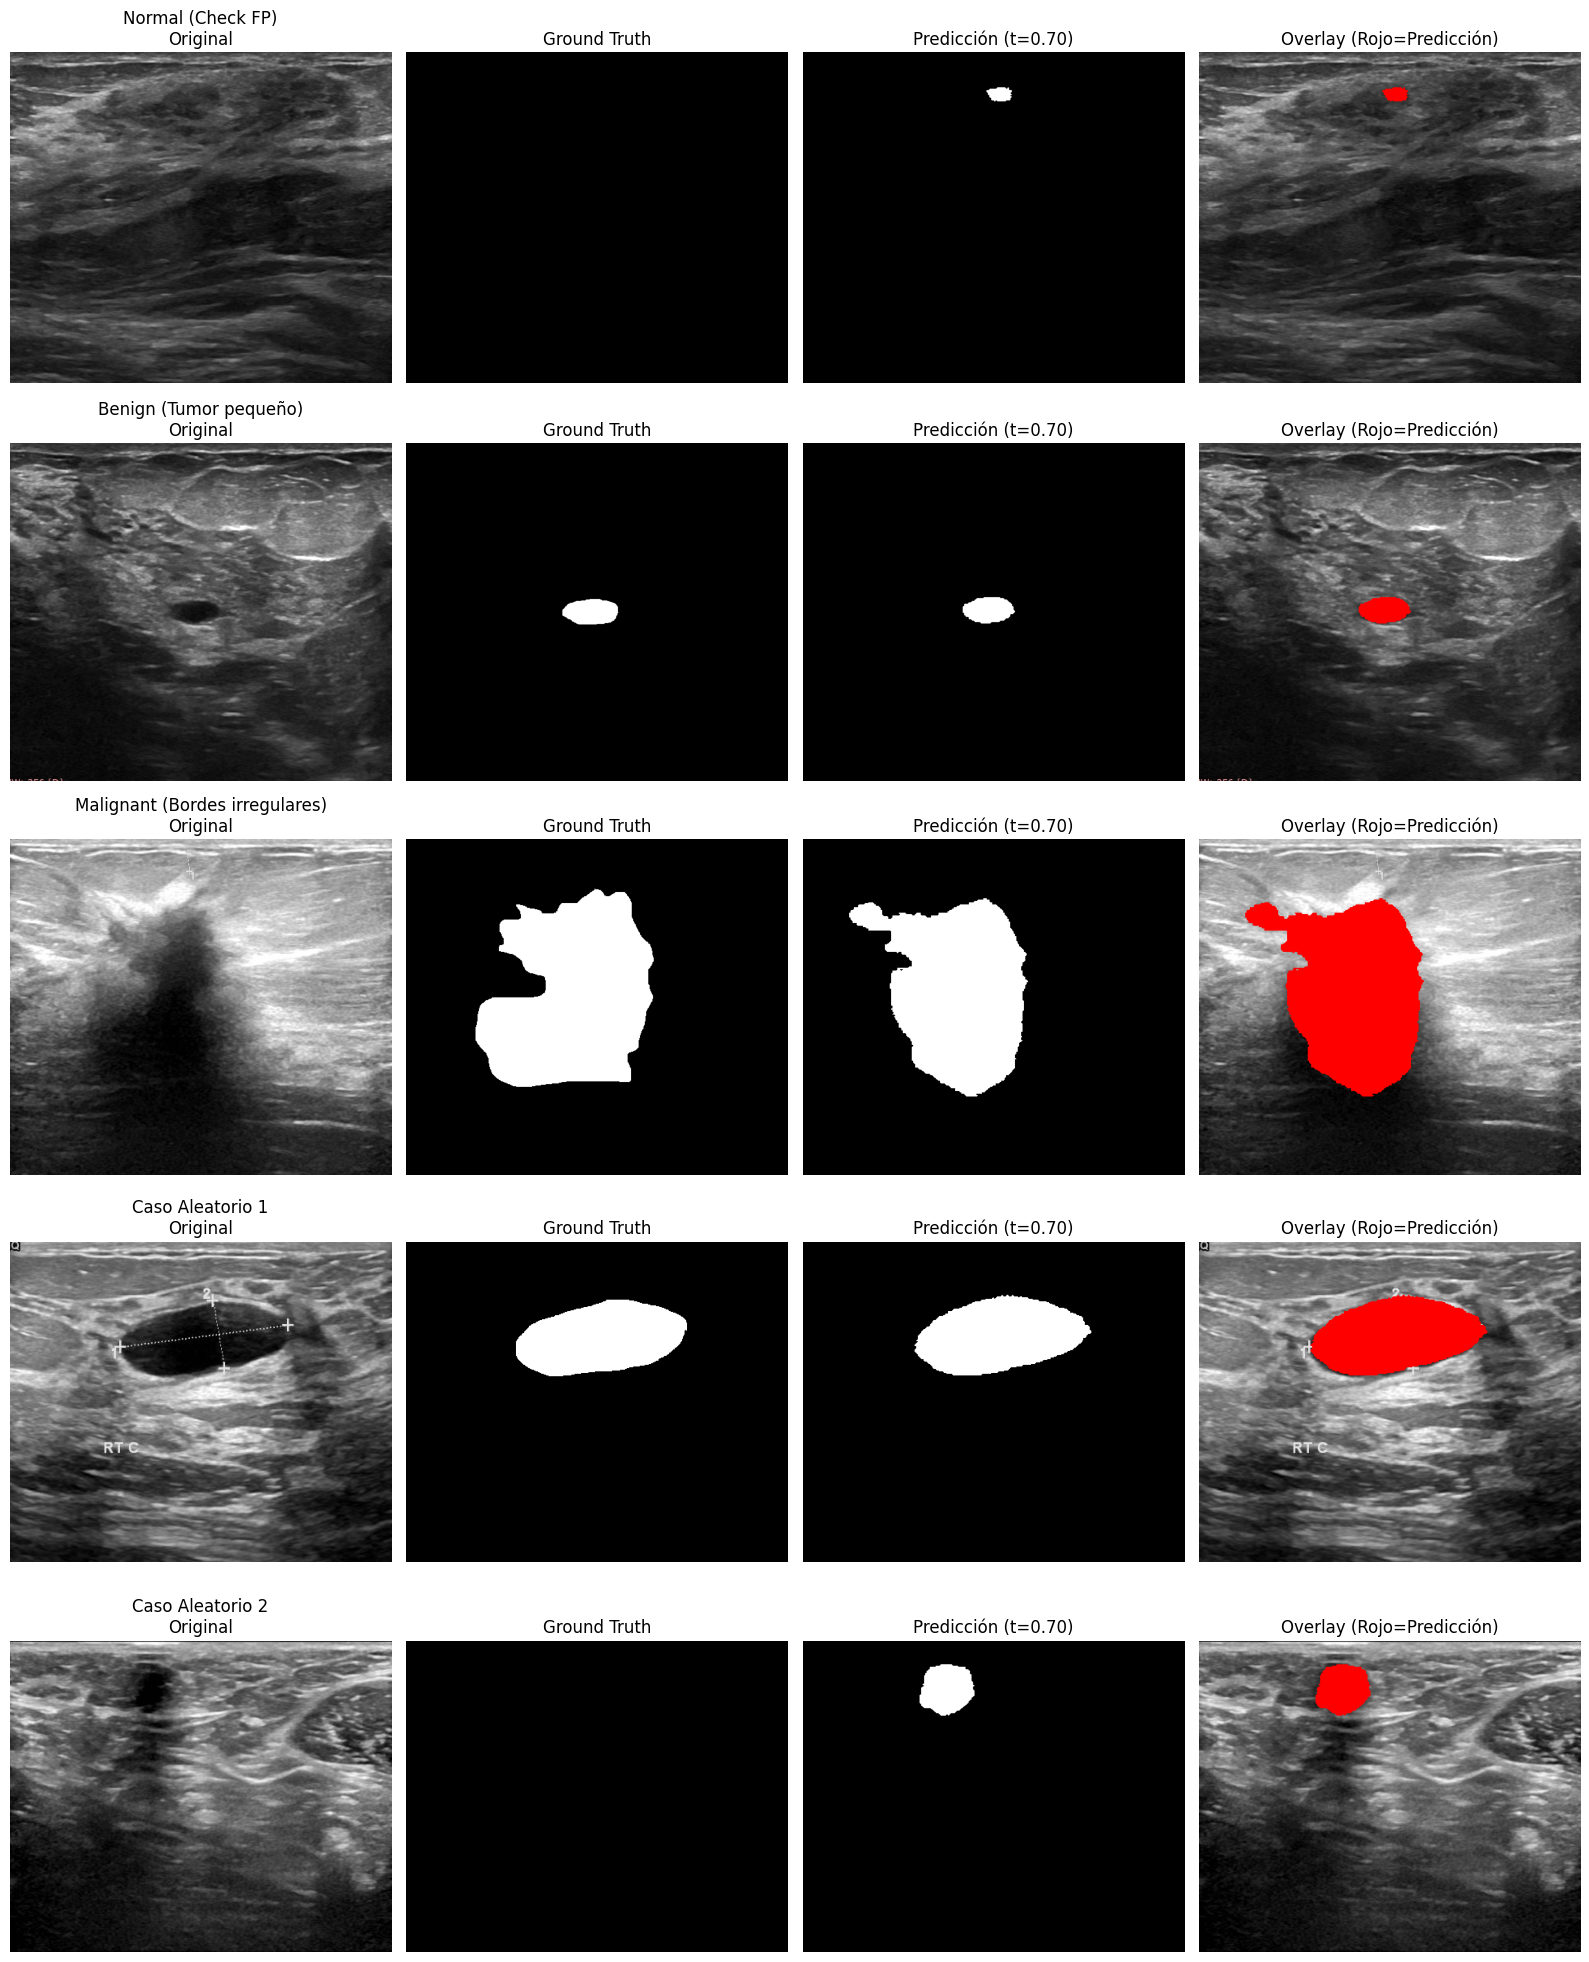

In [ ]:
# ============================================================
# SOLUTION TASK 9.2: QUALITATIVE ERROR ANALYSIS
# ============================================================
import cv2

# We select 5 specific cases
idx_normal = val_df[val_df['class'] == 'normal'].index[0]
idx_benign = val_df[val_df['class'] == 'benign'].index[0]
idx_malignant = val_df[val_df['class'] == 'malignant'].index[0]
idx_rand1, idx_rand2 = val_df.sample(2).index

selected_indices = [idx_normal, idx_benign, idx_malignant, idx_rand1, idx_rand2]
class_names = ['Normal (Check FP)', 'Benign (Small tumor)', 'Malignant (Irregular borders)', 'Random Case 1', 'Random Case 2']

fig, axes = plt.subplots(5, 4, figsize=(16, 20))
model.eval()

for row_idx, (idx, title) in enumerate(zip(selected_indices, class_names)):
    row = val_df.loc[idx]

    # 1. Load data
    img = cv2.imread(row['image_path'])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_h, original_w = img_rgb.shape[:2]

    mask_gt = np.zeros((original_h, original_w), dtype=np.uint8)
    if row['mask_path'] and Path(row['mask_path']).exists():
        mask_gt = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
    mask_gt_bin = (mask_gt > 127).astype(np.float32)

    # 2. Preprocess for the model
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_norm = img_resized.astype(np.float32) / 255.0

    # ImageNet normalization
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_norm = (img_norm - mean) / std

    # KEY: Make sure it's float32
    img_tensor = torch.tensor(img_norm, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    # 3. Predict
    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.sigmoid(logits)
        mask_pred_resized = (probs > best_threshold).float().squeeze().cpu().numpy()

    mask_pred = cv2.resize(mask_pred_resized, (original_w, original_h))
    mask_pred_bin = (mask_pred > 0.5).astype(np.uint8)

    # 4. Visualize
    axes[row_idx, 0].imshow(img_rgb)
    axes[row_idx, 0].set_title(f"{title}\nOriginal")
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(mask_gt_bin, cmap='gray')
    axes[row_idx, 1].set_title("Ground Truth")
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(mask_pred_bin, cmap='gray')
    axes[row_idx, 2].set_title(f"Prediction (t={best_threshold:.2f})")
    axes[row_idx, 2].axis('off')

    overlay = img_rgb.copy()
    overlay[mask_pred_bin == 1] = [255, 0, 0]
    axes[row_idx, 3].imshow(overlay)
    axes[row_idx, 3].set_title("Overlay (Red=Prediction)")
    axes[row_idx, 3].axis('off')

plt.tight_layout()
plt.show()

## Block 9.3: Closing the Loop — From Calibration to Submission
### The same type of pipeline you already built in Practice 7

This task asks you to repeat, conceptually, the same inference pipeline of Block 7.4: load the test image, preprocess it the same as in training, pass it through the model, threshold it, resize the mask to the original size, convert to RLE and save the CSV. The only thing that changes is **which threshold value you use to binarize**: before it was a fixed `0.5`, now it's your `best_threshold` calibrated in Task 1.

> **Key idea:** if you find yourself rewriting all the preprocessing from scratch, stop for a moment — it's practically the same code you already wrote in Practice 7, with a single different value.

### Closing the threshold loop

In Block 9.1 you calibrated `best_threshold` using the **validation** set — precisely because you couldn't use train (biased) or test (you don't have its masks to measure Dice there). Now, in Task 9.3, that same fixed value is applied to the **test** set, without recalculating it. This is the complete and correct cycle of a hyperparameter: it is calibrated once on validation, and that frozen value is what gets deployed on new data.

> **Key idea:** if at this point you found yourself recalculating the threshold on test itself, you'd be repeating exactly the error that Block 9.1 explained why to avoid.

### A technical nuance before resizing the mask

The model always predicts at `IMG_SIZE` resolution, but each test image has its own original size — so at some point you'll have to resize the predicted mask back to `(original_h, original_w)`, just like in Practice 7.

Here there's a detail worth being clear about **before** writing the code, because it's an easy bug to commit without any error being raised: if you resize a mask that is **already binary** (only zeros and ones) with `cv2.resize`, the default interpolation can mix values at the tumor borders, leaving pixels with intermediate values (neither 0 nor 1):

```
small binary mask (IMG_SIZE)  →  cv2.resize  →  no longer purely 0/1 at the borders
```

You have two valid ways to avoid it:

1. **Binarize, resize, and binarize again**: apply the threshold at `IMG_SIZE`, resize that mask, and apply a second cut (for example `> 0.5`) after the resize to clean up the intermediate values introduced by the interpolation.
2. **Resize the probabilities, binarize only once**: resize the continuous output of `sigmoid()` (not the binary mask) to the original size, and apply `best_threshold` a single time, already at the final resolution.

Either one is correct. What is **not** correct is resizing a binary mask and passing it directly to `mask_to_rle` without that second cut — the resulting RLE would have tumor boundaries slightly different from what your model actually predicted, with nothing in the execution warning you about the problem.

### Why a different file name

The task asks to save `submission_final.csv`, not to overwrite the `submission.csv` from Practice 7. Keeping different names per version lets you compare on the Kaggle Leaderboard what concrete improvement each step brought (baseline → augmentation → optimal threshold), instead of losing that traceability by overwriting the same file every time.

### The complete pipeline, at a glance

```
P7: Trained model (fixed threshold 0.5)
        │
P8: Does augmentation improve?  →  definitive model
        │
Block 9.1: best_threshold calibrated on validation
        │
Task 9.3: definitive model + best_threshold  →  submission_final.csv
```

### Quick summary

| Concept | Main idea |
|----------|-----------------|
| Reuse | The pipeline is conceptually the one from Block 7.4; only the threshold used changes |
| Hyperparameter cycle | Calibrated once on validation, applied fixed on test |
| Binarize vs resize | Resizing an already-binary mask reintroduces intermediate values; you must re-binarize or resize the probabilities before thresholding |
| File naming | Versioning the submissions lets you attribute the improvement to each specific change |

## Task 9.3: Generating the Final Submission
The moment of truth has arrived. Let's apply everything we've learned (best model, best threshold) to the test set to generate our definitive `submission.csv`.

### Instructions:
1. Iterate over all the images in the `test/images` folder.
2. Preprocess each image exactly the same as in Task 9.2.
3. Predict the mask using the **`best_threshold`** you found in Task 9.1.
4. Resize the mask to the original image size.
5. Convert the mask to **RLE** format (using the `mask_to_rle` function from P6).
6. Save the results in a DataFrame and export it as **`submission_final.csv`**.

> **CHECKPOINT P9.2:** Download the `submission_final.csv`, upload it to Kaggle and show the professor your new score on the Leaderboard. Go for the top 10!

In [ ]:
# ============================================================
# SOLUTION TASK 9.3: GENERATION OF THE FINAL SUBMISSION
# ============================================================

import os
import pandas as pd

test_img_dir = DATA_DIR / 'test' / 'images'
test_images = sorted(list(test_img_dir.glob('*.png')))

results = []

print(f"Generating final submission with threshold = {best_threshold:.2f}...")
print(f"Total test images: {len(test_images)}")
print("="*60)

model.eval()

with torch.no_grad():
    for idx, img_path in enumerate(test_images):
        # 1. Load image
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        original_h, original_w = img_rgb.shape[:2]

        # 2. Preprocess
        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
        img_norm = img_resized.astype(np.float32) / 255.0

        # ImageNet normalization
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img_norm = (img_norm - mean) / std

        # KEY: dtype=torch.float32 to avoid the DoubleTensor error
        img_tensor = torch.tensor(img_norm, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

        # 3. Predict
        logits = model(img_tensor)
        probs = torch.sigmoid(logits)
        mask_pred_resized = (probs > best_threshold).float().squeeze().cpu().numpy()

        # 4. Resize to the original size
        mask_pred = cv2.resize(mask_pred_resized, (original_w, original_h))
        mask_binary = (mask_pred > 0.5).astype(np.uint8)

        # 5. Convert to RLE
        rle = mask_to_rle(mask_binary)
        results.append({'Id': img_path.name, 'Expected': rle})

        # Show progress
        if (idx + 1) % 50 == 0:
            print(f"    Progress: {idx + 1}/{len(test_images)} images")

# Create DataFrame and save
submission_df = pd.DataFrame(results)
submission_df.to_csv('submission_final.csv', index=False)

# Statistics
total_images = len(submission_df)
images_with_tumor = (submission_df['Expected'] != '').sum()
images_without_tumor = (submission_df['Expected'] == '').sum()

print("\n" + "="*60)
print("FINAL SUBMISSION GENERATED!")
print("="*60)
print(f"File: submission_final.csv")
print(f"Total images: {total_images}")
print(f"Images with tumor detected: {images_with_tumor}")
print(f"Images without tumor (normal): {images_without_tumor}")
print(f"Detection percentage: {(images_with_tumor/total_images)*100:.1f}%")
print(f"Threshold used: {best_threshold:.2f}")
print("\nFinal steps:")
print("   1. Download the file from Colab (Files -> submission_final.csv)")
print("   2. Go to Kaggle -> My Submissions -> Upload")
print("   3. Watch your new position on the Leaderboard!")

Generando submission final con threshold = 0.70...
Total de imágenes de test: 234
    Progreso: 50/234 imágenes
    Progreso: 100/234 imágenes
    Progreso: 150/234 imágenes
    Progreso: 200/234 imágenes

¡SUBMISSION FINAL GENERADA!
Archivo: submission_final.csv
Total de imágenes: 234
Imágenes con tumor detectado: 195
Imágenes sin tumor (normales): 39
Porcentaje de detección: 83.3%
Threshold usado: 0.70

Pasos finales:
   1. Descarga el archivo desde Colab (Archivos -> submission_final.csv)
   2. Ve a Kaggle -> My Submissions -> Upload
   3. ¡Observa tu nueva posición en el Leaderboard!


# Practice 10: TTA, Final Submission and Project Defense
## Single session (30 Nov Group A / 2 Dec Group B)

### Session objectives:
1. Implement **Test Time Augmentation (TTA)** to improve the robustness of the predictions on the test set.
2. Generate the definitive **Final Submission** for the Kaggle Leaderboard.
3. Structure and rehearse the **Oral Defense** of the project.

### The "Kaggle Trick": TTA
In real competitions, the model doesn't predict only once. The original image, its flipped version, and sometimes rotated versions are passed through it. Then the probabilities are averaged. This reduces variance and usually raises the Dice Score by 1% to 3%.

> **CHECKPOINT P10:** Show the professor:
> 1. The TTA code working.
> 2. The screenshot of your final position on the Kaggle Leaderboard.
> 3. The outline of your oral presentation.

## Block 10.1: Test Time Augmentation — the Reverse of Data Augmentation
### TTA is the counterpart of Data Augmentation, but at inference

In Practice 8 you trained with `HorizontalFlip(p=0.5)` to force the model to be **invariant** to horizontal flips: so it learns that a tumor is still the same tumor, whether it's on the left or the right side of the image. TTA exploits that learned invariance, but at prediction time, not training time:

| | Data Augmentation (P8) | Test Time Augmentation (P10) |
|---|---|---|
| When is it applied? | During training | During inference |
| What does it transform? | The training images | The test image, several times |
| What does it achieve? | The model *learns* to be invariant | Exploits that invariance to *average* several opinions of the same model |
| Do the weights change? | Yes, it trains with them | No, the model is already fixed |

> **Key idea:** if the model never saw horizontally flipped examples during training, there's no reason to expect its prediction on the flipped image to be reliable — TTA only works because Practice 8 prepared the model for this.

### Why you must undo the flip of the prediction before averaging

When you flip the input image and pass it through the model, the mask you get also comes out flipped: a tumor that in the original image is on the left, in the prediction on the flipped image appears "on the right" of the canvas. If you averaged that prediction directly with the original one (without returning it to its orientation), you'd be mixing pixel `(x, y)` of one with pixel `(width - x, y)` of the other — two positions that don't represent the same point of the image. That's why the algorithm explicitly asks to flip the prediction back **before** averaging: it's the same principle as Block 7.1 (a geometric transformation must be undone symmetrically so things stay aligned).

### Average probabilities, not already-binarized masks

Notice the exact order of the algorithm: `probs_final = (probs_orig + probs_flip) / 2`, and **only then** `best_threshold` is applied. This is not a coincidence — it's the same principle of "threshold once, at the end" you saw in Practice 9. If you first binarized each prediction separately and then averaged two masks of 0s and 1s, you'd lose the information of *how much confidence* each view had: a pixel where one view says 0.9 and the other 0.6 (clear tumor in both) and another where one says 0.51 and the other 0.49 (doubtful boundary) can give the same result if you binarize before averaging, but they are very different situations if you average the probabilities first.

### The cost of TTA: inference time, not training time

Data Augmentation and TTA have their computational cost on opposite sides of the process:

| Technique | Where it costs more time |
|---------|----------------------------|
| Data Augmentation | Training (each epoch processes different variations) |
| TTA | Inference (each test image is predicted 2 times: original + flipped) |

With 234 test images and only 2 views per image, the extra cost is affordable in Colab. If instead of 1 flip you used 4 or 8 different transformations, the inference time would grow proportionally — TTA is a trade-off decision between available time and expected Dice improvement.

### Why horizontal flip and not any other transformation

In Block 8.1 you established that a 90° rotation or a vertical flip are not clinically valid transformations for breast ultrasound (they change the anatomical orientation in a way that would never occur in a real acquisition) — and that's why the augmentation pipeline never used them. The same rule applies here: TTA should only use transformations the model **was trained to live with**. Applying TTA with a 90° rotation, for example, would average a reliable prediction (the original) with a prediction on an input the model never learned to interpret — at best it doesn't help, at worst it worsens the result.

> **Question to think about:** the statement says TTA "usually" raises the Dice by 1% to 3%, not that it always guarantees it. According to the above, in what specific circumstance would you expect TTA with horizontal flip *not* to improve, or even worsen, the result?

### Quick summary

| Concept | Main idea |
|----------|-----------------|
| TTA vs Data Augmentation | DA trains invariance; TTA exploits it at inference, without touching the weights |
| Undo the flip | The prediction on the flipped image also comes out flipped; you must revert it before comparing pixel by pixel |
| Average before thresholding | Averaging probabilities preserves confidence nuances that averaging binary masks loses |
| Cost | Extra time at inference (proportional to the number of views), not in training |
| Valid transformations | Only the ones the model saw during training (Block 8.1) |

## Task 10.1: Implementation of Test Time Augmentation (TTA)
### What is TTA?
During training we use *Data Augmentation* so the model sees more data.
During inference (test), we use *Test Time Augmentation* so the model "sees" the same image from different perspectives and averages its confidence.

### The algorithm:
1. Take the original test image.
2. Predict the probability mask (`probs_orig`).
3. Flip the image horizontally (`flip_img`).
4. Predict the mask of the flipped image (`probs_flip`).
5. Flip the prediction back to the original orientation.
6. **Average**: `probs_final = (probs_orig + probs_flip) / 2`.
7. Apply the `best_threshold` on `probs_final`.

### Instructions:
1. Define a function `predict_with_tta(model, img_tensor, device, threshold)`.
2. Inside it, do the normal prediction.
3. Apply `torch.flip(img_tensor, [-1])` to flip the image.
4. Make the second prediction and flip the result back with `torch.flip()`.
5. Average both outputs and binarize with the threshold.

In [ ]:
# ============================================================
# SOLUTION TASK 10.1: INFERENCE FUNCTION WITH TTA
# ============================================================

def predict_with_tta(model, img_tensor, device, threshold=0.5):
    """
    Performs inference using Test Time Augmentation (Horizontal Flip).
    """
    model.eval()
    with torch.no_grad():
        # 1. Original prediction
        logits_orig = model(img_tensor)
        probs_orig = torch.sigmoid(logits_orig)

        # 2. Flip image and predict
        img_flipped = torch.flip(img_tensor, [-1])
        logits_flip = model(img_flipped)
        probs_flip = torch.sigmoid(logits_flip)

        # 3. Flip the prediction back to the original orientation
        probs_flip_restored = torch.flip(probs_flip, [-1])

        # 4. Average and threshold
        probs_final = (probs_orig + probs_flip_restored) / 2.0
        mask_pred = (probs_final > threshold).float()

    return mask_pred

print("TTA function defined correctly")

Función TTA definida correctamente


## Block 10.2: The Last Details Before the Definitive Submission
### Why `dtype=torch.float32` is "KEY"

The code explicitly marks `torch.tensor(img_norm, dtype=torch.float32)`. This is not a generic precaution — without it, you'd run into a real and quite cryptic error the first time it happens to you.

`numpy` uses `float64` (double precision) by default in many arithmetic operations, while your model weights are `float32` (single precision) — that's the standard in neural networks, because doubling the precision doesn't improve the result and does double the memory used. If you build the input tensor without fixing the dtype and `numpy` sneaks a `float64` in some intermediate step, PyTorch will return something like `RuntimeError: expected scalar type Float but found Double` in the first convolutional layer — the model can't multiply `float32` weights by a `float64` input.

> **Key idea:** explicitly fixing `dtype=torch.float32` when creating the tensor is safer than trusting that all the previous operations (`.astype(np.float32)`, subtractions, divisions) keep the precision you expect at every step.

### Nesting `torch.no_grad()` is not an error

The comment `# Optional, the function already handles it, but good practice` points at something real: `predict_with_tta` already wraps its content in `torch.no_grad()` (Task 10.1). Putting a second `with torch.no_grad():` around the call, in this task's loop, is redundant but **not an error** — PyTorch context managers can be nested without problem; the second `no_grad()` simply confirms a condition that was already active. It's a reasonable defensive practice: if in the future someone modifies `predict_with_tta` and forgets the internal `no_grad()`, the external one would still protect the inference loop.

### The resize and the second threshold, once again

In the post-processing section (`mask_resized = cv2.resize(mask_np, ...)` followed by `mask_binary = (mask_resized > 0.5)`) you'll recognize exactly the Block 9.3 pattern: `predict_with_tta` returns a mask already binarized at `IMG_SIZE` resolution; when you resize it to the original size with `cv2.resize`, the interpolation reintroduces intermediate values at the borders, and that's why that second `> 0.5` is needed before passing it to `mask_to_rle`. The pattern doesn't change for using TTA — only that the mask you resize now comes from averaging two views instead of one.

### The complete journey of a submission

At this point, each submission you've uploaded to Kaggle represents one more layer over the previous one:

```
submission.csv          (P7):  baseline model, fixed threshold 0.5
submission_final.csv    (P9):  best model + calibrated best_threshold
submission_TTA.csv      (P10): best model + best_threshold + average of 2 views (TTA)
```

Each file should, in principle, beat (or at least match) the previous one on the Leaderboard — if it doesn't, that's a useful signal for Task 9.3 (review what's failing) rather than something to hide in the oral defense.

### Quick summary

| Concept | Main idea |
|----------|-----------------|
| `dtype=torch.float32` | Avoids the error of mixing `float64` (numpy) with the model's `float32` weights |
| Nested `torch.no_grad()` | Safe and redundant, not an error — reinforces a protection that already existed |
| Resize + second threshold | Same pattern as Block 9.3: interpolation reintroduces intermediate values at the borders |
| Submission progression | Each CSV adds an improvement over the previous one: baseline → optimal threshold → TTA |

## Task 10.2: Generating the Final Submission with TTA
It's the moment of truth. Let's use the TTA function to generate our last `submission.csv`.

### Instructions:
1. Iterate over the images in `test/images`.
2. Preprocess the image (remember the `dtype=torch.float32` to avoid type errors).
3. Call `predict_with_tta()` using your `best_threshold`.
4. Resize the mask to the original size and convert it to RLE.
5. Save the DataFrame as **`submission_TTA.csv`** and upload it to Kaggle.

> **Hint:** TTA doubles the inference time, but on a 234-image dataset in Colab it will only take a few extra minutes. It's worth it!

> **CHECKPOINT P10.1:** Download `submission_TTA.csv` and upload it to Kaggle. Show the professor your new position on the Leaderboard.

In [ ]:
# ============================================================
# SOLUTION TASK 10.2: FINAL SUBMISSION WITH TTA
# ============================================================
import pandas as pd

test_img_dir = DATA_DIR / 'test' / 'images'
test_images = sorted(list(test_img_dir.glob('*.png')))
results = []

print(f"Generating Final Submission with TTA (Threshold = {best_threshold:.2f})...")
print(f"Total images: {len(test_images)}")

for idx, img_path in enumerate(test_images):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_h, original_w = img_rgb.shape[:2]

    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_norm = img_resized.astype(np.float32) / 255.0

    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_norm = (img_norm - mean) / std

    img_tensor = torch.tensor(img_norm, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    # Inference with TTA
    mask_pred = predict_with_tta(model, img_tensor, DEVICE, threshold=best_threshold)

    mask_np = mask_pred.squeeze().cpu().numpy()
    mask_resized = cv2.resize(mask_np, (original_w, original_h))
    mask_binary = (mask_resized > 0.5).astype(np.uint8)

    rle = mask_to_rle(mask_binary)
    results.append({'Id': img_path.name, 'Expected': rle})

    if (idx + 1) % 50 == 0:
        print(f"   Progress: {idx + 1}/{len(test_images)}")

submission_df = pd.DataFrame(results)
submission_df.to_csv('submission_TTA.csv', index=False)

print("\n" + "="*60)
print("END OF THE CHALLENGE! FINAL SUBMISSION GENERATED")
print("="*60)
print(f"File: submission_TTA.csv")
print(f" Images with tumor: {(submission_df['Expected'] != '').sum()}")
print(f" Normal images: {(submission_df['Expected'] == '').sum()}")
print("\nUpload this file to Kaggle and compare your score with the P9 one!")

Generando Submission Final con TTA (Threshold = 0.70)...
Total imágenes: 234
   Progreso: 50/234
   Progreso: 100/234
   Progreso: 150/234
   Progreso: 200/234

¡FIN DEL RETO! SUBMISSION FINAL GENERADA
Archivo: submission_TTA.csv
 Imágenes con tumor: 182
 Imágenes normales: 52

¡Sube este archivo a Kaggle y compara tu puntuación con la de la P9!


## Block 10.3: Prepare the Questions, not Only the Slides
### Why the oral defense weighs as much as the code

A model that works but that its author can't explain is, in professional practice, a model that can't be defended before an ethics committee, a skeptical radiologist or a scientific paper reviewer. The oral defense is not a formality added at the end of the project — it's the check that you understood the decisions you made, not only that you copied code that works.

### The question that breaks an unprepared defense: "why?"

The evaluation criteria ask for "critical thinking: not only reading numbers, but explaining why the model fails or succeeds". In practice, this translates into the professor not asking "what Dice Score did you get?" (that's already on the screen) but "why that threshold and not 0.5?", "why does this image fail and this other one not?". If you only memorize the results without understanding the decisions behind them, those questions will catch you blank in front of the professor — which is exactly the moment that counts for the grade.

### Battery of questions to test yourselves before the defense

Review these questions on your own before the defense. Each one corresponds to a Block you've already worked on — if you can't answer one confidently, that's the block you should reread:

| Question | Block where the answer is |
|----------|-----------------------------------|
| Why do you normalize with ImageNet mean/std and not only by dividing by 255? | Block 7.1 (Dataset and DataLoader) |
| Why does the loss function combine Dice + BCE instead of using only one? | Block 7.2 (U-Net and Loss Function) |
| What's the difference between `model.train()` and `model.eval()`, and why does it matter? | Block 7.3 (Training Loop) |
| Why can't you compute your real Dice on the test set? | Block 7.4 (From Training to Submission) |
| Why is a 90° rotation not a valid augmentation here? | Block 8.1 (Data Augmentation) |
| Why do you have to "denormalize" the image to visualize it? | Block 8.2 (Verifying Visually) |
| Why did you reinitialize the model instead of continuing to train the baseline? | Block 8.3 (Repeating an Experiment) |
| Why is looking only at the final Val Dice not enough to conclude that a model is better? | Block 8.4 (Reading a Comparison) |
| Why is the threshold calibrated on validation and not on train or test? | Block 9.1 (The Threshold as a Hyperparameter) |
| Why can a "normal" image never produce a False Negative? | Block 9.2 (Reading the Errors) |
| Why do you have to resize the mask carefully before the RLE? | Block 9.3 (Closing the Loop) |
| Why should TTA with horizontal flip work, but one with a 90° rotation not? | Block 8.1 (Data Augmentation) |

> **Key idea:** if a classmate from another group asked you these questions without warning, could you answer without looking at the notebook? That's the real test of whether you're ready for the defense.

### How to answer when you don't know something

If the professor asks something you don't remember precisely, the worst possible answer is to invent something that sounds good but is incorrect — an experienced evaluator detects it immediately, and penalizes the attempt to "pad" more than honesty. It's better to say "I'm not sure of the exact reason, but what we observed was..." and describe what you actually saw in your own results. Technical honesty is also part of what is evaluated as "technical clarity".

### Quick summary

| Concept | Main idea |
|----------|-----------------|
| Why the defense matters | A model you can't explain is not professionally defensible |
| The key question | It's not "what result did you get" but "why did you make that decision" |
| Prior self-assessment | Review the per-block question table before the defense, not only the slides |
| Facing a real doubt | Honesty about what was observed, better than an invented justification |

## Task 10.3: Preparing the Oral Defense
You've done the work of biomedical engineers. Now it's time to communicate it. The oral defense is 50% of the Practice 10 grade.

### Recommended presentation structure (3-5 minutes per person):

1. **Clinical Context (1 min):**
   * What is the BUSI dataset? Why is it important to segment breast tumors?
   * What clinical challenge do the "normal" images pose?
2. **EDA and Preprocessing (1 min):**
   * Class distribution.
   * Explanation of the RLE format and why it's necessary.
3. **Architecture and Training (2 min):**
   * Why U-Net? (Mention Skip Connections).
   * Loss function: Why do we combine Dice + BCE?
   * Data Augmentation strategy: What worked and what didn't? (Show comparison plots).
4. **Error Analysis and Threshold (1.5 min):**
   * Show the threshold optimization plot.
   * Show 1 success case and 1 failure case (False Positive/Negative) and explain *clinically* why it happened.
5. **Conclusions and TTA (0.5 min):**
   * How much did the final score improve with TTA?
   * What would you do if you had one more month for the project?

### Evaluation Criteria:
* **Technical clarity:** Correct use of terminology (Dice, BCE, Overfitting, TTA).
* **Critical thinking:** Not only reading numbers, but explaining *why* the model fails or succeeds.
* **Teamwork:** Both group members must speak.

> **CHECKPOINT P10.2:** Show the professor the outline of your presentation before leaving class. Good luck in the defense!